# Installation

For detailed installation instructions, see the [official documentation](https://gsbdbi.github.io/torch-choice/install/) or the [README](https://github.com/gsbDBI/torch-choice).

1. **From source (latest features, recommended):**
   ```bash
   # First clone the repository.
   git clone https://github.com/gsbDBI/torch-choice.git

   # Using uv (fast, recommended):
   ./scripts/setup_uv.sh complete
   
   # Or manual install:
   cd torch-choice
   pip install -e .
   ```

2. **From PyPI (stable release version):**
   ```bash
   pip install torch-choice
   ```

This notebook assumes `torch-choice` is already installed. If running locally, activate your environment first.

# Discrete Choice Models with Torch-Choice: Multinomial Logit

This notebook is structured for a ~50-minute lecture in a classroom setting, but you could also use it as a self-study resource; if you are going through this notebook yourself, we highly recommend you to go through the official documentation of Torch-Choice as well.

We introduce Multinomial Logit (MNL) and show how to estimate it using Torch-Choice.

## Introduction and Background
Discrete choice models predict choices among alternatives under the Random Utility Model. Torch-Choice is a PyTorch-based library for scalable, flexible discrete choice modeling:
- GPU acceleration and efficient CPU support via PyTorch.
- Flexible specification: formula strings or programmatic dicts; supports availability masks and outside options.
- Built-in optimization (SGD/Adam/LBFGS) and standard errors via Hessian.
- With PyTorch Lightning integration, so you can add pre-defined or customized training ``callbacks`` to your model (e.g., learning rate scheduler, early stopping, etc.)
- ChoiceDataset for efficient tensor-based data handling.

In this tutorial, we will:
- Present MNL theory, IIA, and coefficient interpretation.
- Fit MNL on ModeCanada, a toy dataset of travel mode choice.
- Demonstrate data management with ChoiceDataset.
- Show regularization, post-estimation analysis, and user-specific coefficients.

**Note:** This tutorial focuses on Multinomial Logit. For Nested Logit models, please refer to the [official documentation](https://gsbdbi.github.io/torch-choice/) and the torch-choice paper.

Requirements: Python 3.9+, PyTorch, Torch-Choice. A GPU is optional.

### Notation Reference Table

| Symbol | Meaning | Shape/Notes |
|---|---|---|
| $u$ | user index | Optional in this notebook (ModeCanada has no user-level variation) |
| $s$ | session (choice occasion) index | Rows in the dataset; also called choice instances |
| $i$ | alternative (item) index | Modes: air, bus, car, train; total $I$ items |
| $A(s)$ | available alternative set in session $s$ | Typically all 4 modes in ModeCanada; availability masks possible |
| $\mathcal{V}_{uis}$ | total utility of alt. $i$ | $\mathcal{V}_{uis} = \mu_{uis} + \varepsilon_{uis}$ |
| $\mu_{uis}$ | deterministic (systematic) utility | Linear in features, e.g., $x_{uis}^\top \beta + \alpha_i$ |
| $\varepsilon_{uis}$ | random shock | i.i.d. Gumbel (Type-I Extreme Value) in MNL |
| $P(i \mid u, s)$ | choice probability of alt. $i$ | Softmax: $\exp(\mu_{uis}) / \sum_{j\in A(s)} \exp(\mu_{ujs})$ |
| $x_{uis}$ | observed features for alt. $i$, session $s$ | In ModeCanada: cost, frequency, OVT, IVT; plus session income |
| $\beta$ | coefficient vector(s) | Can vary by item via `(constant|..)`, `(item|..)`, `(item-full|..)` |
| $\alpha_i$ | item intercept (fixed effect) | One item normalized to 0 for identification |
| $I$ | number of alternatives | Here $I=4$ |
| $N$ | number of choice instances | Equal to dataset length |
| itemsession_∗ | item-by-session features | Tensor shape $(N, I, p)$ |
| session_∗ | session-only features | Tensor shape $(N, q)$ |
| (Nested logit) $B_k$ | set (nest) of similar alts. | Partition of items into nests |
| (Nested logit) $I_{uk}$ | inclusive value of nest $k$ | $\ln \sum_{j\in B_k} \exp(Y_{uj}/\lambda_k)$ |
| (Nested logit) $\lambda_k$ | dissimilarity (inclusive value) parameter | $\lambda_k\in(0,1]$; $=1$ reduces to MNL |

This table aligns with the symbols used below for MNL and nested logit derivations.


## Multinomial Logit (MNL) Background

**The Random Utility Model (RUM) Framework:**
- Discrete choice models are rooted in the **Random Utility Model (RUM)** framework, which posits that decision-makers choose the alternative that maximizes their **utility**.
- **Utility** represents the satisfaction, value, or benefit a decision-maker derives from choosing a particular alternative. It is a numerical measure that captures preferences, with higher utility indicating a more preferred option.
- Each alternative provides a utility composed of a systematic (observed) component and an unobserved random shock.
- The decision-maker observes the full utility (including the random component) and selects the alternative with the highest total utility.
- However, the researcher only observes systematic features—such as price, quality, and individual characteristics—and must model the choice probabilities implied by the distribution of unobserved shocks.
- This framework connects utility maximization with probabilistic choice, enabling econometric estimation and prediction.

**Mathematical Formulation:**
- Under the RUM, user $u$ in session $s$ faces alternatives $i \in A(s)$.
- **Session**: you can think of it as the time period, or more commonly, the choice occasion such as time-store visit. We use the session indexed by $s$ instead of time indexed by $t$ because session is more general and can be used for repeated users.

- Utilities are decomposed as:
$$ \mathcal{V}_{uis} = \mu_{uis} + \varepsilon_{uis}, $$
where $\mu_{uis}$ is the systematic utility (observable to the researcher) and $\varepsilon_{uis}$ is an unobserved random shock.

**Multinomial Logit (MNL) Choice Probabilities:**
- When $\varepsilon_{uis}$ are independent and identically distributed (i.i.d.) [Type-I Extreme Value (Gumbel)](https://en.wikipedia.org/wiki/Gumbel_distribution), we can prove that the choice probabilities take the **multinomial logit (MNL)** form:
$$ P(i \mid u, s) = \frac{\exp(\mu_{uis})}{\sum_{j\in A(s)} \exp(\mu_{ujs})}. $$

**Linear Specification and Interpretation:**
- A common linear specification is

$$
\mu_{uis} = x_{uis}^\top \beta + \alpha_i
$$

where $x_{uis}$ are observed features (e.g., cost, frequency, travel time), specific to the alternative $i$ and the session $s$, and potentially user $u$ and $\beta, \alpha_i$ are coefficients.

- Coefficients admit log-odds interpretations: a one-unit increase in $x_k$ changes the log-odds of choosing alternative $i$ over $j$ by $\beta_k$, so $\exp(\beta_k)$ is an odds ratio.

## General Form of Utility in TorchChoice:
### Form of Coefficients/Trainable Parameters
- TorchChoice supports a flexible, general utility specification that allows coefficients to vary across users and items. The general form is:

$$
\mu_{uis} = \sum_{k \in \text{constant}} x^{(k)}_{uis} \beta^{(k)} + \sum_{k \in \text{user}} x^{(k)}_{us} \beta^{(k)}_u + \sum_{k \in \text{item}} x^{(k)}_{uis} \beta^{(k)}_i + \sum_{k \in \text{user-item}} x^{(k)}_{uis} \beta^{(k)}_{ui}
$$

where each observable $x^{(k)}$ is associated with one of the following **coefficient variation types**:
  
 | Variation Type | Description | Number of Parameters |
 |----------------|-------------|----------------------|
 | `constant` | Coefficient shared across all users and items (e.g., universal price sensitivity) | $p$ |
 | `user` | User-specific coefficient, constant across items (e.g., individual income effects) | $U \times p$ |
 | `item` | Item-specific coefficient, constant across users (e.g., mode-specific time sensitivities). The first item coefficient is normalized to zero for identification. | $(I-1) \times p$ |
 | `item-full` | Same as `item`, but explicitly models all item coefficients without normalization | $I \times p$ |
 | `user-item` | Both user and item-specific coefficients (rarely used due to parameter explosion). First item coefficients set to zero. | $U \times (I-1) \times p$ |
 | `user-item-full` | Fully flexible user-item interaction without normalization | $U \times I \times p$ |

**Practical Notes:**
- Most applications use `constant` and `item` variations, sometimes `user`.
- TorchChoice automatically handles identification constraints (normalizing first item coefficients to zero)
- Specification can be done via R-like formulas: `"(cost|constant) + (income|item) + (intercept|item)"` or programmatic dictionaries
- This flexibility enables modeling heterogeneous preferences while maintaining interpretability

**⚠️ Caution on Model Complexity and Identification:**
- **Over-parameterized models cannot be identified on small datasets.** The number of estimable parameters grows rapidly with model complexity:
  - `constant`: $p$ parameters (where $p$ is feature dimension)
  - `item`: $(I-1) \times p$ parameters (for $I$ items)
  - `user`: $U \times p$ parameters (for $U$ users)
  - `user-item`: $U \times (I-1) \times p$ parameters — can quickly become unmanageable!
- **Rule of thumb**: Ensure your dataset has many more observations than parameters. With $N$ observations and $K$ parameters, aim for $N \gg K$ (e.g., $N > 10K$ at minimum).
- **Symptoms of under-identification**: Large standard errors, `nan` in coefficient estimates, non-convergence, or unstable results across runs.
- **Solutions**: Use simpler specifications, add regularization (`L1` or `L2`), collect more data, or aggregate rare categories.

## Forms of Observable/Feature/Covariate Tensor
**Observable/Feature Tensor Variations:**

In addition to coefficient variations, TorchChoice supports different **observable tensor structures** to match the data:

| Observable Type | Shape | Description | Example |
|----------------|-------|-------------|---------|
| `user_*` | `(U, D)` | Features varying by user only | User demographics (age, income) |
| `item_*` | `(I, D)` | Features varying by item only | Item attributes (brand, category) |
| `session_*` | `(S, D)` | Features varying by session only | Session-level context (weather, time of day) |
| `taste_*` | `(U, I, D)` | Features varying by user and item | User-item compatibility scores |
| `price_*` | `(S, I, D)` | Features varying by session and item | Price of each item in each session |
| `itemsession_*` | `(S, I, D)` | Alias for `price_*` (more intuitive name) | Price, availability, quality per item-session |

where `U` is number of users, `I` is number of items, `S` is number of sessions, and `D` is feature dimension.

**Note:** `taste_*` observables are not recommended for large datasets due to the potentially massive `(U × I × D)` tensor size.

These naming conventions allow TorchChoice to automatically infer the correct tensor shapes and broadcasting behavior during utility computation.

**Key Properties:**
- MNL exhibits **Independence of Irrelevant Alternatives (IIA)**: the ratio of choice probabilities for any two alternatives depends only on their own utilities, not on other alternatives.
- For identifiability, one item intercept is normalized to zero (TorchChoice enforces a baseline for item-level terms).

### Additional Observable Types (Advanced)

For completeness, `torch-choice` also supports additional observable types that combine multiple dimensions. These are less commonly used but available when needed:

| Observable Type | Shape | Description | Example Use Case |
|----------------|-------|-------------|------------------|
| `useritem_*` (or `taste_*`) | `(U, I, D)` | Features varying by user and item | User ratings of items, user-item compatibility scores |
| `usersession_*` | `(U, S, D)` | Features varying by user and session | User's shopping cart size in each session |
| `usersessionitem_*` | `(U, S, I, D)` | Features varying by user, session, and item | Number of times user $u$ purchased item $i$ before session $s$ |

**⚠️ Memory Considerations:**
- `useritem_*` tensors can become very large: $(U \times I \times D)$ entries. With 10,000 users, 1,000 items, and 10 features, this requires 100 million entries!
- `usersessionitem_*` is even more memory-intensive: $(U \times S \times I \times D)$ entries
- **Best practice**: Avoid these types when possible. Often you can redesign your data to use more efficient types. For example:
  - Instead of useritem observables, use item observables + user observables and model interactions through coefficients
  - Instead of usersessionitem, define sessions more granularly so user-session pairs become unique, reducing to itemsession observables

As mentioned in the torch-choice paper: *"The user-session-item observable tensor can be extremely large and cause out-of-memory issues even at moderate levels of U, I, and S."*


## Independence of Irrelevant Alternatives (IIA)

**Derivation of IIA:**
- A key property of MNL is the Independence of Irrelevant Alternatives (IIA).
- To derive it, consider the ratio of probabilities for any two alternatives $j$ and $k$ in choice set $A(s)$:

$$
\frac{P(j \mid u, s)}{P(k \mid u, s)} = \frac{\frac{\exp(\mu_{ujs})}{\sum_{i\in A(s)} \exp(\mu_{uis})}}{\frac{\exp(\mu_{uks})}{\sum_{i\in A(s)} \exp(\mu_{uis})}} = \frac{\exp(\mu_{ujs})}{\exp(\mu_{uks})} = \exp(\mu_{ujs} - \mu_{uks}).
$$

**Key Insight:**
- Notice that the denominator (sum over all alternatives) cancels out, leaving only the difference in utilities between $j$ and $k$.
- This means the relative probability of choosing $j$ over $k$ depends only on their own utilities, not on the presence or characteristics of other alternatives.
- This is the IIA property.

**Implication:**
- IIA implies odds between any two alternatives depend only on their utilities (conditional on the session):

$$ \frac{P(j \mid u, s)}{P(k \mid u, s)} = \exp\big(\mu_{ujs}-\mu_{uks}\big). $$
### Why IIA can be useful in practice
 - **Computational efficiency**: Adding or removing alternatives doesn't require re-estimating the entire model, since relative probabilities between existing alternatives remain unchanged.
 - **Closed-form estimation**: Analytic log-likelihood and gradients enable fast LBFGS/Adam and straightforward standard errors via the Hessian.
 - **Scalability**: No simulation needed; vectorizes well on CPU/GPU and handles large datasets and moderate numbers of alternatives.
 - **Interpretability**: Coefficients have clear log-odds interpretations that don't depend on the full choice set.
 - **Simplicity**: The model structure is parsimonious and easy to estimate, making it a good baseline for many applications.
 - **Counterfactuals**: Policy and attribute change simulations are simple (softmax updates) without Monte Carlo integration.
 - **Elasticities and odds**: Own- and cross- elasticities and odds ratios are easy to compute and communicate.
 - **Diagnostics baseline**: Serves as a fast benchmark for likelihood-ratio tests and comparisons against nested/mixed logit.
 - **Identification and regularization**: Minimal constraints (baseline intercept) and clean integration of L1/L2 penalties help stabilize estimates.
 - **Engineering simplicity**: Stable, interpretable outputs fit well into analytics/BI pipelines and A/B experimentation workflows.
 - **Sufficient for many contexts**: When alternatives are truly independent (e.g., choosing between unrelated products), IIA is a reasonable assumption.

### IIA: caveats and practical guidance
- **Close substitutes**: MNL can misallocate substitution when alternatives are similar; consider nested or mixed logit, or alternative-specific error structures.
- **Probability effects**: Coefficients are on log-odds; marginal probability effects depend on the competing set, so interpret in context.
- **Counterfactuals**: For entry/exit of similar alternatives, re-estimate or use a richer model to capture realistic substitution patterns.
- **Validation**: Use domain knowledge and model comparison (e.g., nested logit with $\lambda<1$) to assess IIA plausibility.
- **Baseline role**: Keep MNL as a fast, interpretable baseline for diagnostics and iteration.

## Example (Red Bus/Blue Bus paradox):

**Setup:**
- Suppose initially there's a **car** and a **red bus**, each with 50% share.
- If we add a **blue bus** identical to the red bus, IIA predicts each mode gets 1/3 share.

**The Problem:**
- But intuitively, the two buses should split the original bus share (25% each), leaving car at 50%.
- This illustrates how IIA can be unrealistic when alternatives are close substitutes.

## If I don't like IIA, what can I do?
The IIA assumption may be violated when alternatives are close substitutes—a common scenario in real-world datasets where items naturally cluster into categories or product groups. For instance, in retail choice modeling (such as the Costco shopping behavior analysis that motivated the development of `torch-choice`), items are typically organized into categories such as food, electronics, and household goods. In such contexts, the IIA property often represents an overly restrictive assumption that fails to capture realistic substitution patterns within categories.
 
 
- **Nested Logit Model**: Relaxes IIA by grouping similar alternatives into "nests" with correlated errors
    - Allows substitution patterns to differ within vs. across nests
    - Example: Red bus and blue bus in a "bus nest" vs. car in a separate nest
    - Controlled by nest-specific dissimilarity parameters (λ): λ=1 recovers MNL, λ<1 allows correlation
    - Particularly useful when some datasets naturally group items into buckets or categories (e.g., grocery shopping where items fall into produce, dairy, meat, etc.; transportation modes grouped by type; product categories in retail)
- **Mixed Logit Model**: Allows random coefficients that vary across decision-makers
    - Captures unobserved heterogeneity in preferences
    - Flexible substitution patterns without pre-specified nesting structure
    - Requires simulation for estimation (more computationally intensive)
- **Random Coefficients Model**: Similar to mixed logit, models taste variation explicitly
- **Hierarchical Bayes Model**: Fully Bayesian approach with prior distributions on parameters
    - Naturally handles uncertainty and shrinkage
    - Can incorporate rich hierarchical structures
- **Bayesian Choice Model**: General Bayesian framework for discrete choice
    - Posterior inference via MCMC or variational methods
    - Provides full posterior distributions, not just point estimates

# Data Management: Building ChoiceDataset from Scratch

**ChoiceDataset Structure:**
- Core component for managing choice data in TorchChoice
- Efficiently stores observables as tensors with clear naming conventions
- Supports various feature types: item-session, session-only, user-specific, etc.
- Can be moved between CPU and GPU seamlessly

**Key naming conventions (matching the official documentation):**
- `user_*`: Features varying by user only, shape `(U, D)`
- `item_*`: Features varying by item only, shape `(I, D)`
- `session_*`: Features varying by session only, shape `(S, D)`
- `taste_*`: Features varying by user and item, shape `(U, I, D)` [not recommended for large datasets]
- `price_*`: Features varying by session and item, shape `(S, I, D)`
- `itemsession_*`: Alias for `price_*`, shape `(S, I, D)`

where `U` = num_users, `I` = num_items, `S` = num_sessions, `D` = feature dimension.

**Required fields:**
- `item_index`: Tensor of **chosen items**, shape `(N,)` where `N` is the number of choice observations
- Optional: `session_index`, `user_index`, `item_availability`


## The Choice Problem: Choice Records

Before diving into data management, let's formally define the basic unit of analysis in choice modeling.

**Definition (Choice Records):** A **choice record**, also referred to as simply a **record**, is a triplet (**user**, **item-chosen**, **session**), where:
- **user** is the identity of the user who made a choice
- **item-chosen** is the item the user chose  
- **session** is characterized by contextual information such as the time-varying characteristics of the choice alternatives and the identities of available choice alternatives

Each row in the central part of a ChoiceDataset corresponds to one choice record, identified by indices $(u^{(n)}, i^{(n)}, s^{(n)})$ where $n$ is the record index.

This definition aligns with how the `torch-choice` paper formalizes choice data: we observe $N$ choice records from $U$ users, $I$ items, and $S$ sessions.


In [1]:
import numpy as np
import pandas as pd
import torch
from torch_choice.data import ChoiceDataset, utils

## Method 1: Building ChoiceDataset with EasyDataWrapper (from long-format DataFrame)

The `torch-choice` package provides the `EasyDatasetWrapper` class for converting pandas DataFrames in "long" format (similar to what's used in Stata and R) into `ChoiceDataset` objects. This is often the easiest way to get started if your data is already in a tabular format.

**What is "long format"?**
In long format, each row represents one alternative in one choice record. If a user chooses among 4 alternatives, that choice record spans 4 rows in the DataFrame. This is the format used by most statistical packages like Stata's `clogit` and R's `mlogit`.

**Key advantage**: You don't need to manually construct tensors - the wrapper handles all the tensor construction and reshaping for you.

### Required columns in your DataFrame:

The `EasyDatasetWrapper` requires a long-format DataFrame with these columns:

1. **`purchase_record_column`**: Identifies each choice record (also called "case" in Stata). Rows with the same value constitute one choice record.
2. **`item_name_column`**: Identifies the alternative/item in each row (e.g., product name, transportation mode)
3. **`choice_column`**: Binary indicator (0/1) showing which alternative was chosen. Exactly one row per record should have value 1.
4. **`user_index_column`** (optional): Identifies which user made the choice
5. **`session_index_column`** (optional): Identifies the session/context of the choice

### Two ways to add observables:

**Method A: From columns of the main DataFrame**
```python
from torch_choice.utils.easy_data_wrapper import EasyDatasetWrapper

wrapper = EasyDatasetWrapper(
    main_data=df,
    purchase_record_column='record_id',
    choice_column='purchase',
    item_name_column='product',
    user_index_column='user_id',
    session_index_column='session_id',
    user_observable_columns=['age', 'income'],      # User attributes
    item_observable_columns=['brand', 'quality'],    # Item attributes
    session_observable_columns=['day_of_week'],      # Session context
    itemsession_observable_columns=['price', 'discount']  # Varies by item & session
)

dataset = wrapper.choice_dataset
```

**Method B: From separate DataFrames**
Useful when the same observable appears in multiple rows (e.g., user demographics repeated for each alternative):

```python
# Extract user demographics (one row per user)
user_df = df.groupby('user_id')[['age', 'income']].first().reset_index()

# Extract item attributes (one row per item)  
item_df = df.groupby('product')[['brand', 'quality']].first().reset_index()

# Use these separate dataframes
wrapper = EasyDatasetWrapper(
    main_data=df,
    purchase_record_column='record_id',
    choice_column='purchase',
    item_name_column='product',
    user_index_column='user_id',
    session_index_column='session_id',
    user_observable_data={'demographics': user_df},
    item_observable_data={'attributes': item_df},
    itemsession_observable_columns=['price', 'discount']  # Can mix methods!
)

dataset = wrapper.choice_dataset
```

**Why use separate DataFrames?** 
- More memory efficient (no duplicate data)
- Cleaner when you have panel data (same user making multiple choices)
- Easier to maintain separate data sources

For a complete example with real data, see the [Easy Data Management Tutorial](https://gsbdbi.github.io/torch-choice/easy_data_management/) in the official documentation.


## Example: Building ChoiceDataset from Scratch (Synthetic Data)

This example demonstrates all observable types supported by TorchChoice. We'll create random synthetic data step-by-step to illustrate the data structure.

### Step 0: Note that all index-array should be dense!



### Step 1: Define Dataset Dimensions

First, we specify the size of our dataset and the number of unique entities.


In [2]:
# Set up dimensions for synthetic dataset
num_users = 10
num_items = 4
num_sessions = 500
length_of_dataset = 10000  # Number of choice observations

print(f"Creating synthetic dataset with:")
print(f"  - {num_users} users")
print(f"  - {num_items} items")
print(f"  - {num_sessions} sessions")
print(f"  - {length_of_dataset:,} total choice observations")


Creating synthetic dataset with:
  - 10 users
  - 4 items
  - 500 sessions
  - 10,000 total choice observations


**Sampling distribution:**

$$\mathbf{X}^{(user)} \in \mathbb{R}^{U \times D_{user}}, \quad X^{(user)}_{ud} \sim \mathcal{N}(0, 1)$$

where $U = 10$ users and $D_{user} = 128$ user-specific features.


### Step 2: Create User Observables

User observables have shape `(num_users, D)` where `D` is the number of features. These represent user-specific attributes that don't vary across sessions or items (e.g., age, income, demographics).


In [3]:
# Examples: age, income, education level, past purchase history, etc.
user_obs = torch.randn(num_users, 128)
print(f"user_obs shape: {user_obs.shape}")
print(f"Interpretation: Each of {num_users} users has {user_obs.shape[1]} demographic/behavioral features")


user_obs shape: torch.Size([10, 128])
Interpretation: Each of 10 users has 128 demographic/behavioral features


**Sampling distribution:**

$$\mathbf{X}^{(item)} \in \mathbb{R}^{I \times D_{item}}, \quad X^{(item)}_{id} \sim \mathcal{N}(0, 1)$$

where $I = 4$ items and $D_{item} = 64$ item-specific features.


### Step 3: Create Item Observables

Item observables have shape `(num_items, D)`. These represent item-specific attributes that don't vary across users or sessions (e.g., brand, category, product specifications).


In [4]:
# Create item_obs: 64 features for each of the 4 items
# Examples: product quality, brand reputation, category, specifications, etc.
item_obs = torch.randn(num_items, 64)
print(f"item_obs shape: {item_obs.shape}")
print(f"Interpretation: Each of {num_items} items has {item_obs.shape[1]} constant product attributes")


item_obs shape: torch.Size([4, 64])
Interpretation: Each of 4 items has 64 constant product attributes


**Sampling distribution:**

$$\mathbf{X}^{(session)} \in \mathbb{R}^{S \times D_{session}}, \quad X^{(session)}_{sd} \sim \mathcal{N}(0, 1)$$

where $S = 500$ sessions and $D_{session} = 10$ session-specific features.


### Step 4: Create Session Observables

Session observables have shape `(num_sessions, D)`. These represent context-specific attributes that vary by session but are constant across items and users (e.g., weather, day of week, market conditions).


In [5]:
# Create session_obs: 10 features for each of the 500 sessions
# Examples: day of week, weather, promotional period, market conditions, etc.
session_obs = torch.randn(num_sessions, 10)
print(f"session_obs shape: {session_obs.shape}")
print(f"Interpretation: Each of {num_sessions} sessions has {session_obs.shape[1]} contextual features")


session_obs shape: torch.Size([500, 10])
Interpretation: Each of 500 sessions has 10 contextual features


**Sampling distribution:**

$$\mathbf{X}^{(price)} \in \mathbb{R}^{S \times I \times D_{price}}, \quad X^{(price)}_{sid} \sim \mathcal{N}(0, 1)$$

where $S = 500$ sessions, $I = 4$ items, and $D_{price} = 12$ price/itemsession features.


### Step 5: Create Price/ItemSession Observables

Price observables (also called `itemsession_*`) have shape `(num_sessions, num_items, D)`. These represent attributes that vary by both session and item (e.g., price, stock level, display position).


In [6]:
# Create price_obs: 12 features for each item in each session
# Examples: price, discount level, stock availability, display location, etc.
price_obs = torch.randn(num_sessions, num_items, 12)
print(f"price_obs shape: {price_obs.shape}")
print(f"Interpretation: For each of {num_sessions} sessions and {num_items} items,")
print(f"                we have {price_obs.shape[2]} time-varying item attributes")


price_obs shape: torch.Size([500, 4, 12])
Interpretation: For each of 500 sessions and 4 items,
                we have 12 time-varying item attributes


**Sampling distributions:**

For each observation $n \in \{1, \ldots, N\}$ where $N = 10{,}000$:

$$i_n \sim \text{Discrete Uniform}\{0, 1, \ldots, I-1\} = \text{Discrete Uniform}\{0, 1, 2, 3\}$$

$$u_n \sim \text{Discrete Uniform}\{0, 1, \ldots, U-1\} = \text{Discrete Uniform}\{0, 1, \ldots, 9\}$$

$$s_n \sim \text{Discrete Uniform}\{0, 1, \ldots, S-1\} = \text{Discrete Uniform}\{0, 1, \ldots, 499\}$$

where $i_n$ is the chosen item, $u_n$ is the user, and $s_n$ is the session for observation $n$.


### Step 6: Generate Choice Observations (Indices)

Now we create the actual choice data: which user chose which item in which session. In a real dataset, these would come from observations. Here we generate them randomly for demonstration.


In [7]:
# Generate random choice observations
# item_index: which item was chosen in each observation
item_index = torch.LongTensor(np.random.choice(num_items, size=length_of_dataset))

# user_index: which user made each choice
user_index = torch.LongTensor(np.random.choice(num_users, size=length_of_dataset))

# session_index: which session (shopping occasion) each choice occurred in
session_index = torch.LongTensor(np.random.choice(num_sessions, size=length_of_dataset))

print(f"Generated {length_of_dataset:,} random choice observations")
print(f"  - item_index shape: {item_index.shape} (chosen item for each observation)")
print(f"  - user_index shape: {user_index.shape} (user who made each choice)")
print(f"  - session_index shape: {session_index.shape} (session when choice was made)")
print(f"\nExample: Observation 0 shows user {user_index[0].item()} chose item {item_index[0].item()} in session {session_index[0].item()}")


Generated 10,000 random choice observations
  - item_index shape: torch.Size([10000]) (chosen item for each observation)
  - user_index shape: torch.Size([10000]) (user who made each choice)
  - session_index shape: torch.Size([10000]) (session when choice was made)

Example: Observation 0 shows user 0 chose item 2 in session 173


**Availability specification:**

$$\mathbf{A} \in \{0,1\}^{S \times I}, \quad A_{si} = 1 \quad \forall s \in \{0,\ldots,S-1\}, \; i \in \{0,\ldots,I-1\}$$

where $A_{si} = 1$ indicates item $i$ is available in session $s$. In this synthetic example, all items are always available.


### Step 7: Create Item Availability Mask (Optional)

The availability mask is a boolean tensor of shape `(num_sessions, num_items)` indicating which items are available in which sessions. For simplicity, we'll assume all items are always available.


In [8]:
# Create availability mask: all items available in all sessions
item_availability = torch.ones(num_sessions, num_items).bool()
print(f"item_availability shape: {item_availability.shape}")
print(f"All items available: {item_availability.all().item()}")
print(f"\nNote: In real applications, this mask would indicate stockouts, regional restrictions, etc.")


item_availability shape: torch.Size([500, 4])
All items available: True

Note: In real applications, this mask would indicate stockouts, regional restrictions, etc.


### Step 8: Construct the ChoiceDataset

Finally, we combine all components into a `ChoiceDataset` object. The naming conventions (prefixes like `user_`, `item_`, etc.) allow TorchChoice to automatically understand the tensor structures.


In [9]:
# Construct the ChoiceDataset
dataset_synthetic = ChoiceDataset(
    # Required field
    item_index=item_index,
    # Dimension specifications (required when using user_obs, item_obs, etc.)
    num_users=num_users,
    num_items=num_items,
    num_sessions=num_sessions,
    # Optional indices
    user_index=user_index,
    session_index=session_index,
    item_availability=item_availability,
    # Observable tensors - can use any name with the correct prefix
    user_obs=user_obs,        # prefix: user_
    item_obs=item_obs,        # prefix: item_
    session_obs=session_obs,  # prefix: session_
    price_obs=price_obs       # prefix: price_ (or itemsession_)
)

print("="*70)
print("CONSTRUCTED CHOICEDATASET")
print("="*70)
print(dataset_synthetic)
print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Total choice observations: {length_of_dataset:,}")
print(f"Unique users: {num_users}")
print(f"Unique items: {num_items}")
print(f"Unique sessions: {num_sessions}")
print(f"\nObservable tensors:")
print(f"  - user_obs: {user_obs.shape} → user-specific features")
print(f"  - item_obs: {item_obs.shape} → item-specific features")
print(f"  - session_obs: {session_obs.shape} → session-specific features")
print(f"  - price_obs: {price_obs.shape} → item-session features")


CONSTRUCTED CHOICEDATASET
ChoiceDataset(num_items=4, num_users=10, num_sessions=500, label=[], item_index=[10000], user_index=[10000], session_index=[10000], item_availability=[500, 4], user_obs=[10, 128], item_obs=[4, 64], session_obs=[500, 10], price_obs=[500, 4, 12], device=cpu)

DATASET SUMMARY
Total choice observations: 10,000
Unique users: 10
Unique items: 4
Unique sessions: 500

Observable tensors:
  - user_obs: torch.Size([10, 128]) → user-specific features
  - item_obs: torch.Size([4, 64]) → item-specific features
  - session_obs: torch.Size([500, 10]) → session-specific features
  - price_obs: torch.Size([500, 4, 12]) → item-session features


# Let's Start Modelling

In [10]:
# %% cell 10 code

# Enable autoreload for development
%load_ext autoreload
%autoreload 2

# Install if needed (uncomment in Colab)
# !pip install torch_choice

import torch
import pandas as pd
import numpy as np

import torch_choice
from torch_choice.data import ChoiceDataset, load_mode_canada_dataset
from torch_choice.model import ConditionalLogitModel
from torch_choice import run

# Select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

# Shared training configurations
MNL_TRAIN_KWARGS = {
    'num_epochs': 50,
    'learning_rate': 0.01,
    'batch_size': -1,
    'model_optimizer': 'LBFGS',
    'device': device
}

NESTED_TRAIN_KWARGS = {
    'num_epochs': 300,
    'learning_rate': 0.05,
    'batch_size': -1,
    'model_optimizer': 'Adam',
    'device': device
}

Using device: cpu


# Example Dataset:  ["ModeCanada"](https://rdrr.io/rforge/mlogit/man/ModeCanada.html): Mode Choice for the Montreal-Toronto Corridor

Here’s the breakdown for **ModeCanada** (long “person–alternative” format):

**Unit of analysis / identifiers**

* `case` — individual (choice situation) ID
* `alt` — travel mode (levels: `train`, `car`, `bus`, `air`)
* `noalt` — number of alternatives available in that case.

**Dependent variable**

* `choice` — 1 if that alternative was chosen, 0 otherwise.

**Independent variables**

* Alternative-specific attributes:

  * `cost` — monetary cost:  **session-item-specific**, the price of the alternative.
  * `ivt` — in-vehicle time:  **session-item-specific**, in vehicule time
  * `ovt` — out-of-vehicle time:  **session-item-specific**, out vehicule time (e.g., waiting on the platform, transfer time, etc, so always zero if you are driving).
  * `frequency` — service frequency (*often referenced as `freq` in examples*).
* Individual/segment attributes:

  * `income` — traveler income
  * `urban` — indicator for urban residence.

**Unit of Observation (for Educational Purposes)**
* Each individual's choice is observed once.
* We assume each individual appears in exactly one session.
* While this assumption is simplistic, it serves our pedagogical goals: we can conceptualize this as sampling one user per day (i.e., one session), recording the traffic conditions and costs for that session, and observing which transportation mode the user selects.

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/gsbDBI/torch-choice/main/tutorials/public_datasets/ModeCanada.csv')
df = df.query('noalt == 4').reset_index(drop=True)
df.sort_values(by='case', inplace=True)
df.head()
item_index = df[df['choice'] == 1].sort_values(by='case')['alt'].reset_index(drop=True)
item_names = ['air', 'bus', 'car', 'train']
num_items = 4
encoder = dict(zip(item_names, range(num_items)))
item_index = item_index.map(lambda x: encoder[x])
item_index = torch.LongTensor(item_index)
itemsession_cost_freq_ovt = utils.pivot3d(df, dim0='case', dim1='alt',
                                    values=['cost', 'freq', 'ovt'])

itemsession_ivt = utils.pivot3d(df, dim0='case', dim1='alt', values='ivt')
user_income = df.groupby('case')['income'].first()
user_income = torch.Tensor(user_income.values).view(-1, 1)

dataset = ChoiceDataset(item_index=item_index,
                        num_items=num_items,
                        num_users=len(user_income),
                        user_index=torch.arange(len(user_income)),
                        session_index=torch.arange(len(user_income)),
                        num_sessions=len(user_income),
                        itemsession_cost_freq_ovt=itemsession_cost_freq_ovt,
                        user_income=user_income,
                        itemsession_ivt=itemsession_ivt
                        )


## ChoiceDataset overview

**How TorchChoice organizes choice data into efficient tensors:**
- **Item choice index**: `item_index` of shape $(N,)$ gives the chosen alternative per choice instance.
- **Item-by-session features**: tensors of shape $(N, I, p)$ (e.g., cost/freq/OVT or IVT per alternative).
- **Session-only features**: tensors of shape $(N, q)$ (e.g., income for that choice/session).
- **Optional indices**: `user_index`, `session_index` when modeling repeated users or custom sessions.
- **Optional masks**: `item_availability` to handle availability sets; outside option can be modeled explicitly as an additional item.

**In the ModeCanada example loaded above, we have:**
- `itemsession_cost_freq_ovt`: [2779, 4, 3] for item–session varying cost, frequency, OVT
- `itemsession_ivt`: [2779, 4, 1] for item–session varying in-vehicle time
- `user_income`: [2779, 1] for user-level income
- `item_index`: [2779] for the chosen alternative per observation

In [12]:
# what are in this dataset?
print(dataset)

ChoiceDataset(num_items=4, num_users=2779, num_sessions=2779, label=[], item_index=[2779], user_index=[2779], session_index=[2779], item_availability=[], itemsession_cost_freq_ovt=[2779, 4, 3], user_income=[2779, 1], itemsession_ivt=[2779, 4, 1], device=cpu)


MODECANADA DATASET SUMMARY STATISTICS

---------------------------Dataset Overview---------------------------
Number of choice observations: 2,779
Number of alternatives (modes): 4
Number of sessions: 2779
Alternatives: air, bus, car, train

-------------------------Choice Distribution--------------------------
Air       : 1039 choices (37.39%)
Bus       :   10 choices ( 0.36%)
Car       : 1267 choices (45.59%)
Train     :  463 choices (16.66%)

--------------------------Feature Statistics--------------------------

Cost (dollars):
  Air       : mean=153.40, std= 19.92, min=119.05, max=222.90
  Bus       : mean= 26.97, std=  8.08, min= 10.38, max= 60.72
  Car       : mean= 64.89, std= 28.75, min= 20.33, max=186.77
  Train     : mean= 55.64, std= 15.82, min= 26.50, max=115.60

Service Frequency (trips/day):
  Air       : mean= 24.02, std= 13.05, min=  3.00, max= 45.00
  Bus       : mean= 12.06, std=  6.38, min=  1.00, max= 24.00
  Car       : mean=  0.00, std=  0.00, min=  0.00, max=  0

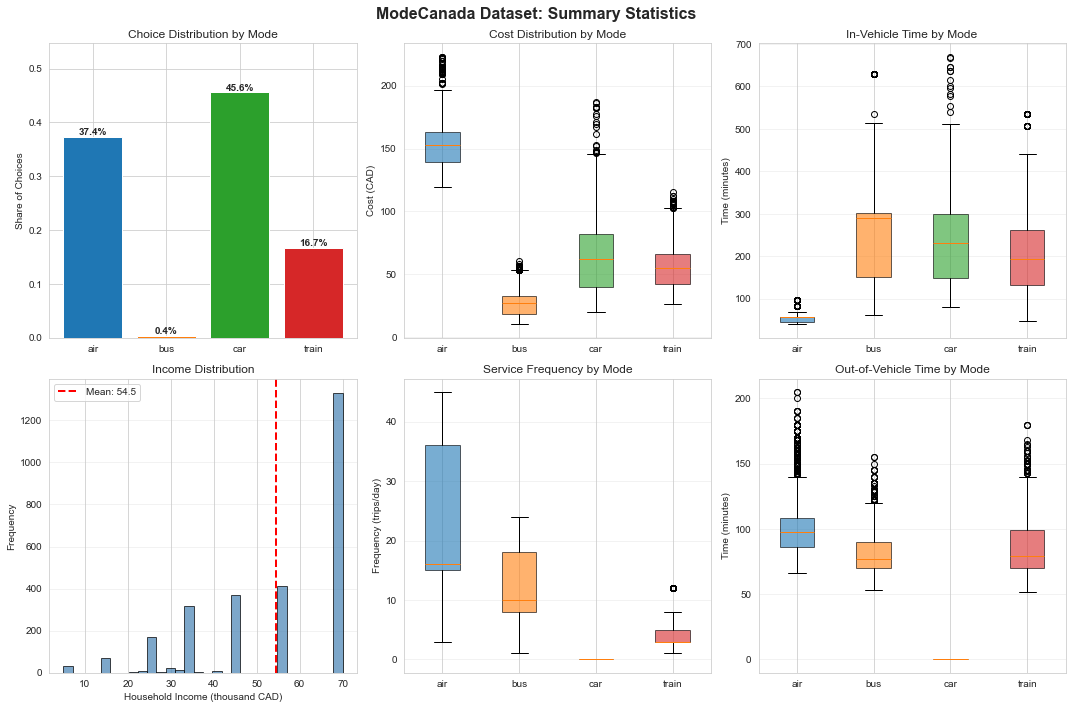


---------------Feature Correlations (across all modes)----------------


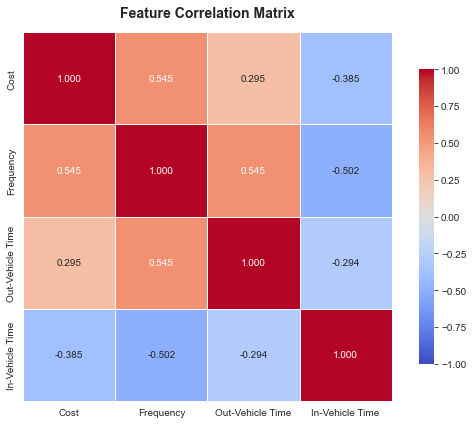


Correlation Matrix:
                   Cost  Frequency  Out-Vehicle Time  In-Vehicle Time
Cost              1.000      0.545             0.295           -0.385
Frequency         0.545      1.000             0.545           -0.502
Out-Vehicle Time  0.295      0.545             1.000           -0.294
In-Vehicle Time  -0.385     -0.502            -0.294            1.000

Key insights:
  - Cost and frequency show negative correlation (cheaper modes tend to be less frequent)
  - In-vehicle time and out-of-vehicle time are positively correlated
  - These patterns reflect real-world tradeoffs in transportation modes


In [13]:
# %% Summary Statistics of the ModeCanada Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style("whitegrid")

print("="*70)
print("MODECANADA DATASET SUMMARY STATISTICS")
print("="*70)

# Basic dataset information
print(f"\n{'Dataset Overview':-^70}")
print(f"Number of choice observations: {len(dataset):,}")
print(f"Number of alternatives (modes): {dataset.num_items}")
print(f"Number of sessions: {dataset.num_sessions}")

# Mode names (based on standard ModeCanada encoding)
mode_names = item_names
print(f"Alternatives: {', '.join(mode_names)}")

# Choice distribution
print(f"\n{'Choice Distribution':-^70}")
choice_counts = torch.bincount(dataset.item_index, minlength=dataset.num_items)
choice_shares = (choice_counts.float() / len(dataset)).cpu().numpy()

for i, (name, count, share) in enumerate(zip(mode_names, choice_counts, choice_shares)):
    print(f"{name.capitalize():10s}: {count:4d} choices ({share:6.2%})")

# Feature statistics
print(f"\n{'Feature Statistics':-^70}")

# Extract features to CPU for analysis
cost_freq_ovt = dataset.itemsession_cost_freq_ovt.cpu().numpy()  # (N, I, 3)
ivt = dataset.itemsession_ivt.cpu().numpy()  # (N, I, 1)
income = dataset.user_income.cpu().numpy()  # (N, 1)

# Cost statistics (feature 0 in cost_freq_ovt)
print(f"\nCost (dollars):")
for i, name in enumerate(mode_names):
    mode_costs = cost_freq_ovt[:, i, 0]
    print(f"  {name.capitalize():10s}: mean={mode_costs.mean():6.2f}, std={mode_costs.std():6.2f}, "
          f"min={mode_costs.min():6.2f}, max={mode_costs.max():6.2f}")

# Frequency statistics (feature 1 in cost_freq_ovt)
print(f"\nService Frequency (trips/day):")
for i, name in enumerate(mode_names):
    mode_freq = cost_freq_ovt[:, i, 1]
    print(f"  {name.capitalize():10s}: mean={mode_freq.mean():6.2f}, std={mode_freq.std():6.2f}, "
          f"min={mode_freq.min():6.2f}, max={mode_freq.max():6.2f}")

# Out-of-vehicle time (feature 2 in cost_freq_ovt)
print(f"\nOut-of-Vehicle Time (minutes):")
for i, name in enumerate(mode_names):
    mode_ovt = cost_freq_ovt[:, i, 2]
    print(f"  {name.capitalize():10s}: mean={mode_ovt.mean():6.2f}, std={mode_ovt.std():6.2f}, "
          f"min={mode_ovt.min():6.2f}, max={mode_ovt.max():6.2f}")

# In-vehicle time
print(f"\nIn-Vehicle Time (minutes):")
for i, name in enumerate(mode_names):
    mode_ivt = ivt[:, i, 0]
    print(f"  {name.capitalize():10s}: mean={mode_ivt.mean():6.2f}, std={mode_ivt.std():6.2f}, "
          f"min={mode_ivt.min():6.2f}, max={mode_ivt.max():6.2f}")

# Income statistics
print(f"\nHousehold Income (thousand CAD):")
print(f"  Mean: {income.mean():.2f}, Std: {income.std():.2f}, Min: {income.min():.2f}, Max: {income.max():.2f}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('ModeCanada Dataset: Summary Statistics', fontsize=16, fontweight='bold')

# 1. Choice distribution
ax = axes[0, 0]
ax.bar(mode_names, choice_shares, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_ylabel('Share of Choices')
ax.set_title('Choice Distribution by Mode')
ax.set_ylim(0, max(choice_shares) * 1.2)
for i, (name, share) in enumerate(zip(mode_names, choice_shares)):
    ax.text(i, share, f'{share:.1%}', ha='center', va='bottom', fontweight='bold')

# 2. Cost distribution by mode
ax = axes[0, 1]
cost_data = [cost_freq_ovt[:, i, 0] for i in range(len(mode_names))]
bp = ax.boxplot(cost_data, labels=mode_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Cost (CAD)')
ax.set_title('Cost Distribution by Mode')
ax.grid(axis='y', alpha=0.3)

# 3. In-vehicle time distribution
ax = axes[0, 2]
ivt_data = [ivt[:, i, 0] for i in range(len(mode_names))]
bp = ax.boxplot(ivt_data, labels=mode_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Time (minutes)')
ax.set_title('In-Vehicle Time by Mode')
ax.grid(axis='y', alpha=0.3)

# 4. Income distribution
ax = axes[1, 0]
ax.hist(income.flatten(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Household Income (thousand CAD)')
ax.set_ylabel('Frequency')
ax.set_title('Income Distribution')
ax.axvline(income.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {income.mean():.1f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 5. Frequency distribution by mode
ax = axes[1, 1]
freq_data = [cost_freq_ovt[:, i, 1] for i in range(len(mode_names))]
bp = ax.boxplot(freq_data, labels=mode_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Frequency (trips/day)')
ax.set_title('Service Frequency by Mode')
ax.grid(axis='y', alpha=0.3)

# 6. Out-of-vehicle time distribution
ax = axes[1, 2]
ovt_data = [cost_freq_ovt[:, i, 2] for i in range(len(mode_names))]
bp = ax.boxplot(ovt_data, labels=mode_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Time (minutes)')
ax.set_title('Out-of-Vehicle Time by Mode')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation analysis
print(f"\n{'Feature Correlations (across all modes)':-^70}")
# Flatten features for correlation analysis
cost_flat = cost_freq_ovt[:, :, 0].flatten()
freq_flat = cost_freq_ovt[:, :, 1].flatten()
ovt_flat = cost_freq_ovt[:, :, 2].flatten()
ivt_flat = ivt[:, :, 0].flatten()

# Compute correlations
features_df = pd.DataFrame({
    'Cost': cost_flat,
    'Frequency': freq_flat,
    'Out-Vehicle Time': ovt_flat,
    'In-Vehicle Time': ivt_flat
})
corr_matrix = features_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, fmt='.3f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))
print("\nKey insights:")
print("  - Cost and frequency show negative correlation (cheaper modes tend to be less frequent)")
print("  - In-vehicle time and out-of-vehicle time are positively correlated")
print("  - These patterns reflect real-world tradeoffs in transportation modes")

**Model specification notes:**
- These tensors can be moved to GPU via `dataset.to(device)`.
- Model specifications (formula or dict) must reference the dataset field names and specify coefficient variation (e.g., `constant`, `item`, `item-full`).


# Our First MNL Model
### Model Specification

In observation $n$, involving user $u^{(n)}$ happend in session $s^{(n)}$, the utility of choosing alternative $j$ is specified as:

$$
V_{u^{(n)}js^{(n)}} = \beta_{\text{cost}} \cdot \text{cost}_{js^{(n)}} + \beta_{\text{freq}} \cdot \text{freq}_{js^{(n)}} + \beta_{\text{ovt}} \cdot \text{ovt}_{js^{(n)}} + \beta_{\text{income},j} \cdot \text{income}_{u^{(n)}} + \beta_{\text{ivt},j} \cdot \text{ivt}_{js^{(n)}} + \alpha_j
$$

**Coefficient Structure:**

| Variable | Coefficient | Variation | Interpretation |
|----------|------------|-----------|----------------|
| Cost | $\beta_{\text{cost}}$ | Constant | Generic cost sensitivity across all modes |
| Frequency | $\beta_{\text{freq}}$ | Constant | Generic frequency preference across all modes |
| Out-vehicle time | $\beta_{\text{ovt}}$ | Constant | Generic OVT disutility across all modes |
| Income | $\beta_{\text{income},j}$ | Item | Mode-specific income effects (3 parameters, item 0 normalized to 0) |
| In-vehicle time | $\beta_{\text{ivt},j}$ | Item-full | Mode-specific IVT effects (4 parameters, all estimated) |
| Intercept | $\alpha_j$ | Item | Mode-specific constants (3 parameters, item 0 normalized to 0) |

**Total Parameters:** 13 (3 constant + 3 income + 4 IVT + 3 intercepts)

This specification allows cost, frequency, and out-of-vehicle time to have consistent effects across modes, while income sensitivity and in-vehicle time preferences vary by transportation alternative.


In [14]:
# Define MNL via formula
formula = '(itemsession_cost_freq_ovt|constant) + (user_income|item) + (itemsession_ivt|item-full) + (intercept|item)'
model = ConditionalLogitModel(formula=formula, dataset=dataset, num_items=dataset.num_items).to(device)
print(model)

ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_cost_freq_ovt[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=3, 3 trainable parameters in total, initialization=normal, device=cpu).
    (user_income[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_cost_freq_ovt[constant]] with 3 parameters, with constant level variation.
X[user_income[item]] with 1 parameters, with item level variation.
X[itemsession_ivt[item-fu

In [15]:
# Shared training configurations
MNL_TRAIN_KWARGS = {
    'num_epochs': 500,
    'learning_rate': 0.003,
    'batch_size': -1,
    'model_optimizer': 'LBFGS',
    'device': device
}

In [16]:
# Train with TorchChoice's run() (MLE via LBFGS)
result_model = run(model, dataset, **MNL_TRAIN_KWARGS)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 13    
------------------------------------------------
13        Trainable params
0         Non-trainable params
13        Total params
0.000     Total estimated model params size (MB)


==================== model received ====================
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_cost_freq_ovt[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=3, 3 trainable parameters in total, initialization=normal, device=cpu).
    (user_income[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_cost_freq_ovt[constant]] with 3 parameters, with constant level variation.
X[user_income[item]] with 1 paramet

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 10 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


Time taken for training: 24.965829849243164
Skip testing, no test dataset is provided.
==================== model results ====================
Log-likelihood: [Training] -1874.3912353515625, [Validation] N/A, [Test] N/A

| Coefficient                           |   Estimation |   Std. Err. |    z-value |    Pr(>|z|) | Significance   |
|:--------------------------------------|-------------:|------------:|-----------:|------------:|:---------------|
| itemsession_cost_freq_ovt[constant]_0 |  -0.0342842  |  0.00709595 |  -4.83152  | 1.35493e-06 | ***            |
| itemsession_cost_freq_ovt[constant]_1 |   0.0928672  |  0.0050995  |  18.211    | 0           | ***            |
| itemsession_cost_freq_ovt[constant]_2 |  -0.0428493  |  0.00322219 | -13.2982   | 0           | ***            |
| user_income[item]_0                   |  -0.0865117  |  0.0183871  |  -4.70503  | 2.53823e-06 | ***            |
| user_income[item]_1                   |  -0.0278074  |  0.0038687  |  -7.18777  | 6.585

### Interpreting Results

**The `run()` output shows coefficient estimates, std errors, z-values, and p-values. Key findings:**

**Generic Coefficients (constant across modes):**
- **Cost** ($\beta_{\text{cost}} = -0.033$***): Each additional dollar reduces utility by 0.033. Highly significant, confirming travelers are price-sensitive.
- **Frequency** ($\beta_{\text{freq}} = +0.093$***): More frequent service substantially increases attractiveness. Strong positive effect.
- **Out-of-vehicle time** ($\beta_{\text{ovt}} = -0.043$***): Waiting/transfer time deters choice. Each additional minute reduces utility.

**Mode-Specific Coefficients:**
- **Income effects** ($\beta_{\text{income},j}$, item variation):
  - Train (item 0): $-0.089$*** — High-income travelers significantly avoid train relative to air (baseline)
  - Car (item 1): $-0.028$*** — High-income travelers moderately avoid car
  - Bus (item 2): $-0.038$*** — High-income travelers avoid bus
  - Interpretation: Wealthier individuals prefer air over ground transportation

- **In-vehicle time** ($\beta_{\text{ivt},j}$, item-full variation):
  - Train (item 0): $+0.060$*** — Positive (may capture train comfort relative to travel time)
  - Car (item 1): $-0.007$ — Not significant
  - Bus (item 2): $-0.006$*** — Negative (as expected)
  - Air (item 3): $-0.001$ — Not significant

- **Intercepts** ($\alpha_j$):
  - Bus (item 2): $+3.27$*** — Highest intercept; strong baseline preference
  - Car (item 1): $+1.84$** — Moderate baseline preference
  - Train (item 0): $+0.67$ — Not significant (close to air baseline)

**Overall assessment:**
- All coefficients highly significant; model fits traveler preferences well.


In [17]:
# Optional: Add L2 regularization
model_reg = ConditionalLogitModel(
    formula=formula,
    dataset=dataset,
    num_items=dataset.num_items,
    regularization='L2',
    regularization_weight=1.0
).to(device)
print(model_reg)
# result_model_reg = run(model_reg, dataset, **MNL_TRAIN_KWARGS)



ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_cost_freq_ovt[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=3, 3 trainable parameters in total, initialization=normal, device=cpu).
    (user_income[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_cost_freq_ovt[constant]] with 3 parameters, with constant level variation.
X[user_income[item]] with 1 parameters, with item level variation.
X[itemsession_ivt[item-fu

# Alternative dictionary-based specification
- Easier to construct models with programmatic control of coefficients.

In [18]:
# Alternative dictionary-based specification
coef_variation_dict = {
    'itemsession_cost_freq_ovt': 'constant',
    'user_income': 'item',  # user-specific income with item-varying coefficients
    'itemsession_ivt': 'item-full',
    'intercept': 'item'
}
num_param_dict = {
    'itemsession_cost_freq_ovt': 3,
    'user_income': 1,
    'itemsession_ivt': 1,
    'intercept': 1
}
model_dict = ConditionalLogitModel(
    coef_variation_dict=coef_variation_dict,
    num_param_dict=num_param_dict,
    num_items=dataset.num_items
).to(device)
print(model_dict)
# result_model_dict = run(model_dict, dataset, **MNL_TRAIN_KWARGS)

ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_cost_freq_ovt[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=3, 3 trainable parameters in total, initialization=normal, device=cpu).
    (user_income[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_cost_freq_ovt[constant]] with 3 parameters, with constant level variation.
X[user_income[item]] with 1 parameters, with item level variation.
X[itemsession_ivt[item-fu

## Advanced Topics: Availability Masks and Outside Options

**Availability Masks:**
- Real choice situations often have constrained choice sets (e.g., not all products in stock)
- TorchChoice supports availability masks via `item_availability` tensor of shape `(num_sessions, num_items)`
- Unavailable items are masked out in utility calculation (set to very large negative value)

**Outside Options:**
- Explicitly model the "no purchase" or "outside" option with utility fixed at 0
- Indicated by `item_index[n] == -1` in the item-index-tensor
- Set `model_outside_option=True` when creating the model


In [19]:
# %% Demonstration: Availability Masks
# Create a small synthetic dataset with varying availability
np.random.seed(100)
N_avail = 500
num_items_avail = 4
num_sessions_avail = N_avail  # each choice is its own session

# Generate features
item_features = torch.randn(N_avail, num_items_avail, 2, device=device)  # e.g., price, quality

# Availability mask: 80% items available on average
# Shape: (num_sessions, num_items)
availability_prob = 0.8
item_availability = (torch.rand(num_sessions_avail, num_items_avail, device=device) < availability_prob)

# Ensure at least one item is available per session
for s in range(num_sessions_avail):
    if not item_availability[s].any():
        item_availability[s, torch.randint(0, num_items_avail, (1,))] = True

# Simulate choices from available sets
def simulate_choices_with_availability(features, availability):
    """Simulate choices using MNL on available items only."""
    N, I, D = features.shape
    # True coefficients for simulation
    beta_true = torch.tensor([[-0.5], [1.0]], device=features.device)  # price(-), quality(+)

    utilities = (features @ beta_true).squeeze(-1)  # (N, I)
    # Mask unavailable items
    utilities_masked = utilities.clone()
    utilities_masked[~availability] = torch.finfo(utilities.dtype).min / 2

    probs = torch.softmax(utilities_masked, dim=1)
    choices = torch.multinomial(probs, 1).squeeze()
    return choices

choices_avail = simulate_choices_with_availability(item_features, item_availability)

# Build dataset with availability mask
dataset_avail = ChoiceDataset(
    item_index=choices_avail,
    session_index=torch.arange(N_avail, device=device),
    itemsession_features=item_features,
    item_availability=item_availability,
    num_items=num_items_avail
).to(device)

print(dataset_avail)
print(f"\nAverage items available per session: {item_availability.float().mean(dim=1).mean():.2f}")
print(f"Share of sessions with all items available: {(item_availability.all(dim=1).float().mean()):.2%}")


ChoiceDataset(num_items=4, num_users=1, num_sessions=500, label=[], item_index=[500], user_index=[], session_index=[500], item_availability=[500, 4], itemsession_features=[500, 4, 2], device=cpu)

Average items available per session: 0.82
Share of sessions with all items available: 43.00%


/Users/tianyudu/Development/torch-choice/torch_choice/data/choice_dataset.py:286: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.
  warnings.warn(f"The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.")


## Repeated Observations with User-Specific Coefficients

**Motivation:**
- In the original ModeCanada dataset, each traveler makes only one choice
- We'll now simulate **repeated observations**: each user makes multiple trips with varying surcharges
- Surchanges should be considered separately from the cost because they brings aditional physical discomfort, for example
- This allows us to estimate **user-specific price coefficients** (e.g., people's altitudes to surcharges) showing that different travelers have different price sensitivities

**Approach:**
1. Take a subset of ModeCanada users and simulate multiple trips per user
2. Add a random surcharge to each trip (representing dynamic pricing, tolls, etc.)
3. Estimate models with:
   - `(surcharge|constant)`: Same surcharge sensitivity for all users
   - `(surcharge|user)`: Different surcharge sensitivity for each user


In [20]:
# %% Create repeated observations dataset from ModeCanada
import numpy as np
import torch
from torch_choice.data import ChoiceDataset

# Set seed for reproducibility
np.random.seed(123)
torch.manual_seed(123)

# Parameters
num_users_subset = 50  # Use 50 users from ModeCanada
trips_per_user = 20    # Each user makes 20 trips
total_obs = num_users_subset * trips_per_user

# Select first 50 users from original dataset
original_indices = torch.arange(num_users_subset)

# Create repeated user indices (each user appears 20 times)
user_index_repeated = torch.repeat_interleave(torch.arange(num_users_subset), trips_per_user)
session_index_repeated = torch.arange(total_obs)

# Extract original features for these users and replicate for trips
original_cost = dataset.itemsession_cost_freq_ovt[original_indices]  # Shape: (50, 4, 3)
original_ivt = dataset.itemsession_ivt[original_indices]  # Shape: (50, 4, 1)
original_income = dataset.user_income[original_indices]  # Shape: (50, 1)

# Replicate features for each trip
# Shape becomes: (1000, 4, 3) by repeating each user's data 20 times
cost_freq_ovt_repeated = original_cost.repeat_interleave(trips_per_user, dim=0)
ivt_repeated = original_ivt.repeat_interleave(trips_per_user, dim=0)
income_repeated = original_income.repeat_interleave(trips_per_user, dim=0)

# Generate random surcharges for each trip and mode
# This simulates dynamic pricing, tolls, peak-hour charges, etc.
surcharge = torch.rand(total_obs, dataset.num_items, 1) * 20.0  # Random 0-20 CAD surcharge

# Simulate choices with user-specific price sensitivity
# Generate random heterogeneous coefficients between -0.08 and -0.01
torch.manual_seed(456)  # Different seed for coefficient generation
true_surcharge_coef = -0.01 - 0.07 * torch.rand(num_users_subset)  # Range: -0.08 to -0.01

# Compute utilities and simulate choices
utilities = torch.zeros(total_obs, dataset.num_items)
for i in range(total_obs):
    user_id = user_index_repeated[i].item()
    # Base utility from cost/freq/ovt (using true ModeCanada coefficients approximately)
    base_util = (
        -0.035 * cost_freq_ovt_repeated[i, :, 0] +  # cost
         0.093 * cost_freq_ovt_repeated[i, :, 1] +  # frequency
        -0.043 * cost_freq_ovt_repeated[i, :, 2]    # OVT
    )
    # Add user-specific surcharge effect
    surcharge_effect = true_surcharge_coef[user_id] * surcharge[i, :, 0]
    utilities[i] = base_util + surcharge_effect

# Add Gumbel noise and select choices
gumbel = -torch.log(-torch.log(torch.rand(total_obs, dataset.num_items)))
item_index_repeated = torch.argmax(utilities + gumbel, dim=1)

# Create augmented dataset with repeated observations
dataset_repeated = ChoiceDataset(
    item_index=item_index_repeated,
    user_index=user_index_repeated,
    session_index=session_index_repeated,
    num_users=num_users_subset,
    num_items=dataset.num_items,
    num_sessions=total_obs,
    itemsession_cost_freq_ovt=cost_freq_ovt_repeated,
    itemsession_ivt=ivt_repeated,
    user_income=income_repeated,
    itemsession_surcharge=surcharge
).to(device)

print("="*70)
print("REPEATED OBSERVATIONS DATASET (Augmented ModeCanada)")
print("="*70)
print(dataset_repeated)
print(f"\nTotal observations: {len(dataset_repeated)}")
print(f"Unique users: {num_users_subset}")
print(f"Trips per user: {trips_per_user}")
print(f"Items (modes): {dataset.num_items}")
print(f"\nTrue surcharge coefficients (heterogeneous):")
print(f"  Mean: {true_surcharge_coef.mean():.4f}")
print(f"  Std:  {true_surcharge_coef.std():.4f}")
print(f"  Min:  {true_surcharge_coef.min():.4f}")
print(f"  Max:  {true_surcharge_coef.max():.4f}")
print(f"\nFirst 10 users:")
for u in range(10):
    print(f"  User {u}: {true_surcharge_coef[u].item():.4f}")


REPEATED OBSERVATIONS DATASET (Augmented ModeCanada)
ChoiceDataset(num_items=4, num_users=50, num_sessions=1000, label=[], item_index=[1000], user_index=[1000], session_index=[1000], item_availability=[], itemsession_cost_freq_ovt=[1000, 4, 3], itemsession_ivt=[1000, 4, 1], user_income=[1000, 1], itemsession_surcharge=[1000, 4, 1], device=cpu)

Total observations: 1000
Unique users: 50
Trips per user: 20
Items (modes): 4

True surcharge coefficients (heterogeneous):
  Mean: -0.0441
  Std:  0.0203
  Min:  -0.0787
  Max:  -0.0101

First 10 users:
  User 0: -0.0577
  User 1: -0.0103
  User 2: -0.0622
  User 3: -0.0656
  User 4: -0.0529
  User 5: -0.0576
  User 6: -0.0787
  User 7: -0.0101
  User 8: -0.0213
  User 9: -0.0514


## Repeated Observations with User-Specific Coefficients

**Motivation:**
- In many applications, we observe the same users making multiple choices over time
- Different users may have different sensitivities to product attributes (e.g., price sensitivity varies by income)
- TorchChoice allows us to model **user-specific coefficients** using the `(variable|user)` variation

**Example Setup:**
We'll create a synthetic dataset where:
- 10 users make 100 choices each (1000 total observations)
- Each choice is among 3 products
- Products have a base price + random surcharge
- **Key feature:** Different users have different price sensitivities (user-specific price coefficients)


In [21]:
MNL_TRAIN_KWARGS['model_optimizer'] = 'Adam'

## MODEL 1: Constant Surcharge Coefficient

In [22]:

formula_constant = '(itemsession_surcharge|constant) + (itemsession_cost_freq_ovt|constant) + (user_income|item) + (intercept|item)'
model_constant = ConditionalLogitModel(
    formula=formula_constant,
    dataset=dataset_repeated,
    num_items=dataset_repeated.num_items
).to(device)

print("\nModel specification:")
print(model_constant)

# Train the model
result_constant = run(
    model_constant,
    dataset_repeated,
    **MNL_TRAIN_KWARGS,
)

print("\n" + "="*70)
print("Interpretation:")
print("="*70)
print("The surcharge coefficient is constant across all users.")
print("This assumes all travelers have the same price sensitivity to surcharges.")


GPU available: True (mps), used: False



Model specification:
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_surcharge[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=1, 1 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_cost_freq_ovt[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=3, 3 trainable parameters in total, initialization=normal, device=cpu).
    (user_income[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_surcharge[constant]] with 1 parameters, with constant level variation.
X[itemsession_cost_freq_ovt[constant]] with 3 parameters, with constan

TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 10    
------------------------------------------------
10        Trainable params
0         Non-trainable params
10        Total params
0.000     Total estimated model params size (MB)
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/traine

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


Time taken for training: 5.451986074447632
Skip testing, no test dataset is provided.
==================== model results ====================
Log-likelihood: [Training] -8982.46875, [Validation] N/A, [Test] N/A

| Coefficient                           |   Estimation |   Std. Err. |    z-value |      Pr(>|z|) | Significance   |
|:--------------------------------------|-------------:|------------:|-----------:|--------------:|:---------------|
| itemsession_surcharge[constant]_0     |    -0.191046 |   0.0241516 |  -7.91029  |   2.66454e-15 | ***            |
| itemsession_cost_freq_ovt[constant]_0 |     0.694808 |   2.92015   |   0.237936 |   0.811931    |                |
| itemsession_cost_freq_ovt[constant]_1 |     0.661112 |   0.42774   |   1.54559  |   0.122202    |                |
| itemsession_cost_freq_ovt[constant]_2 |    -1.01934  |   1.91816   |  -0.531417 |   0.59513     |                |
| user_income[item]_0                   |     1.4368   |   5.51271   |   0.260635 |   

## Model 2: User-specific surcharge coefficient

In [23]:
MNL_TRAIN_KWARGS["learning_rate"] = 0.01

In [24]:
print("="*70)
print("MODEL 2: User-Specific Surcharge Coefficient")
print("="*70)

formula_user = ' (itemsession_surcharge|user) + (itemsession_cost_freq_ovt|constant) + (user_income|item) + (intercept|item) '
model_user = ConditionalLogitModel(
    formula=formula_user,
    dataset=dataset_repeated,
    num_items=dataset_repeated.num_items,
    num_users=dataset_repeated.num_users  # Must specify for user-level variation
).to(device)

print("\nModel specification:")
print(model_user)

# Train the model
result_user = run(
    model_user,
    dataset_repeated,
    **MNL_TRAIN_KWARGS,
)

print("\n" + "="*70)
print("Interpretation:")
print("="*70)
print("Each user has their own surcharge coefficient.")
print("This allows for heterogeneous price sensitivity across travelers.")
print("\nEstimated user-specific surcharge coefficients:")
surcharge_coefs = result_user.get_coefficient('itemsession_surcharge[user]').detach()
print(f"  Mean: {surcharge_coefs.mean():.4f}")
print(f"  Std:  {surcharge_coefs.std():.4f}")
print(f"  Min:  {surcharge_coefs.min():.4f}")
print(f"  Max:  {surcharge_coefs.max():.4f}")
print(f"\nFirst 10 users' surcharge sensitivities:")
for u in range(10):
    print(f"  User {u}: {surcharge_coefs[u].item():.4f} (true: {true_surcharge_coef[u].item():.3f})")


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 59    
------------------------------------------------
59        Trainable params
0         Non-trainable params
59        Total params
0.000     Total estimated model params size (MB)


MODEL 2: User-Specific Surcharge Coefficient

Model specification:
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_surcharge[user]): Coefficient(variation=user, num_items=4, num_users=50, num_params=1, 50 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_cost_freq_ovt[constant]): Coefficient(variation=constant, num_items=4, num_users=50, num_params=3, 3 trainable parameters in total, initialization=normal, device=cpu).
    (user_income[item]): Coefficient(variation=item, num_items=4, num_users=50, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=50, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_surcharge[user]] with 1 parameters, with user level variation.
X[itemsession_cost_freq_ovt[constant]] with 3 pa

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 10 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


Time taken for training: 5.140117883682251
Skip testing, no test dataset is provided.
==================== model results ====================
Log-likelihood: [Training] -864.30224609375, [Validation] N/A, [Test] N/A

| Coefficient                           |   Estimation |   Std. Err. |     z-value |      Pr(>|z|) | Significance   |
|:--------------------------------------|-------------:|------------:|------------:|--------------:|:---------------|
| itemsession_surcharge[user]_0         | -0.092985    |   0.0586675 |  -1.58495   |   0.112978    |                |
| itemsession_surcharge[user]_1         | -0.0335644   |   0.0638568 |  -0.52562   |   0.599152    |                |
| itemsession_surcharge[user]_2         |  0.0117666   |   0.0503047 |   0.233907  |   0.815057    |                |
| itemsession_surcharge[user]_3         |  0.00881369  |   0.0498149 |   0.176929  |   0.859564    |                |
| itemsession_surcharge[user]_4         | -0.0268458   |   0.0477239 |  -0.

### Model Comparison and Visualization

Let's compare the two models and visualize the recovered user-specific coefficients:

**Key Insights:**
1. **Model 1 (constant)** averages price sensitivity across all users, losing individual heterogeneity
2. **Model 2 (user-specific)** recovers the true heterogeneous preferences
3. The user-specific model should show a distribution of coefficients matching the simulated heterogeneity (range: -0.08 to -0.01)

This demonstrates how repeated observations enable estimation of user-specific parameters, revealing preference heterogeneity that would be hidden in a pooled model.


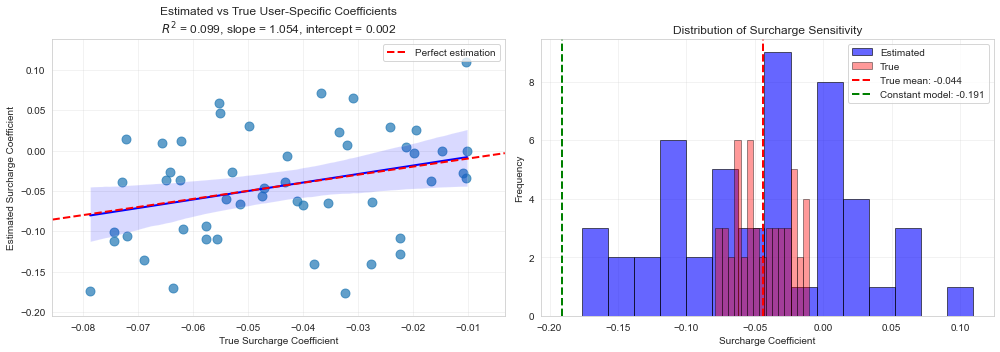


MODEL COMPARISON
Log-Likelihood (Constant):     -8982.47
Log-Likelihood (User-specific): -864.30
Improvement:                    8118.17

The user-specific model fits significantly better by capturing
heterogeneous price sensitivities across travelers.


In [25]:
# %% Visualize user-specific coefficients
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients
const_coef = result_constant.get_coefficient('itemsession_surcharge[constant]').detach().cpu().numpy()[0]
user_coefs = result_user.get_coefficient('itemsession_surcharge[user]').detach().cpu().numpy()
true_coefs = true_surcharge_coef.cpu().numpy()

# Flatten arrays to ensure they are 1D
user_coefs = user_coefs.flatten()
true_coefs = true_coefs.flatten()

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot of estimated vs true coefficients
ax = axes[0]
import seaborn as sns
from scipy import stats

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(true_coefs, user_coefs)

sns.regplot(x=true_coefs, y=user_coefs, ax=ax, scatter_kws={'alpha': 0.7, 's': 80}, line_kws={'color': 'blue', 'linewidth': 2})
# Add 45-degree line for perfect estimation
# Calculate separate ranges for x and y axes
x_min, x_max = true_coefs.min(), true_coefs.max()
y_min, y_max = user_coefs.min(), user_coefs.max()
# Add some padding to each range for better visualization
x_range_padding = (x_max - x_min) * 0.1
y_range_padding = (y_max - y_min) * 0.1
x_plot_min = x_min - x_range_padding
x_plot_max = x_max + x_range_padding
y_plot_min = y_min - y_range_padding
y_plot_max = y_max + y_range_padding
# Draw 45-degree line across the diagonal of the plot area
diag_min = max(x_plot_min, y_plot_min)
diag_max = min(x_plot_max, y_plot_max)
ax.plot([diag_min, diag_max], [diag_min, diag_max], 'r--', label='Perfect estimation', linewidth=2)
ax.set_xlim(x_plot_min, x_plot_max)
ax.set_ylim(y_plot_min, y_plot_max)
ax.set_xlabel('True Surcharge Coefficient')
ax.set_ylabel('Estimated Surcharge Coefficient')
ax.set_title(f'Estimated vs True User-Specific Coefficients\n$R^2$ = {r_value**2:.3f}, slope = {slope:.3f}, intercept = {intercept:.3f}')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Distribution comparison
ax = axes[1]
ax.hist(user_coefs, bins=15, alpha=0.6, label='Estimated', color='blue', edgecolor='black')
ax.hist(true_coefs, bins=15, alpha=0.4, label='True', color='red', edgecolor='black')
ax.axvline(true_coefs.mean(), color='red', linestyle='--',
           label=f'True mean: {true_coefs.mean():.3f}', linewidth=2)
ax.axvline(const_coef, color='green', linestyle='--',
           label=f'Constant model: {const_coef:.3f}', linewidth=2)
ax.set_xlabel('Surcharge Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Surcharge Sensitivity')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Compare log-likelihoods
with torch.no_grad():
    ll_constant = -model_constant.negative_log_likelihood(dataset_repeated, dataset_repeated.item_index).item()
    ll_user = -model_user.negative_log_likelihood(dataset_repeated, dataset_repeated.item_index).item()

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"Log-Likelihood (Constant):     {ll_constant:.2f}")
print(f"Log-Likelihood (User-specific): {ll_user:.2f}")
print(f"Improvement:                    {ll_user - ll_constant:.2f}")
print("\nThe user-specific model fits significantly better by capturing")
print("heterogeneous price sensitivities across travelers.")


In [26]:
# %% Generate repeated observations with user-specific price sensitivity
import numpy as np
import torch
from torch_choice.data import ChoiceDataset
from torch_choice.model import ConditionalLogitModel
from torch_choice import run

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Dataset dimensions
num_users = 10
num_items = 3
num_sessions_per_user = 100
total_sessions = num_users * num_sessions_per_user

# Generate user indices (each user appears 100 times)
user_index = torch.repeat_interleave(torch.arange(num_users), num_sessions_per_user)

# Generate session indices (unique for each observation)
session_index = torch.arange(total_sessions)

# Simulate user-specific price sensitivity (heterogeneous preferences)
# Users 0-4: high price sensitivity (beta ~ -2.0)
# Users 5-9: low price sensitivity (beta ~ -0.5)
true_price_coef_user = torch.tensor([
    -2.0, -1.8, -2.2, -1.9, -2.1,  # High sensitivity users
    -0.5, -0.6, -0.4, -0.5, -0.6   # Low sensitivity users
])

# Generate base prices for each item (constant across sessions)
base_price = torch.tensor([10.0, 15.0, 20.0])

# Generate random surcharges for each session and item
# Shape: (total_sessions, num_items)
surcharge = torch.rand(total_sessions, num_items) * 5.0  # Random surcharge 0-5

# Total price = base_price + surcharge
total_price = base_price.unsqueeze(0) + surcharge  # Shape: (total_sessions, num_items)

# Simulate utility and choices based on user-specific price coefficients
utilities = torch.zeros(total_sessions, num_items)
for i in range(total_sessions):
    user_id = user_index[i].item()
    # Utility = user_specific_price_coef * total_price + noise
    utilities[i] = true_price_coef_user[user_id] * total_price[i]

# Add Gumbel noise and simulate choices
gumbel_noise = -torch.log(-torch.log(torch.rand(total_sessions, num_items)))
utilities_noisy = utilities + gumbel_noise
item_index = torch.argmax(utilities_noisy, dim=1)

# Create ChoiceDataset
dataset_repeated = ChoiceDataset(
    item_index=item_index,
    user_index=user_index,
    session_index=session_index,
    num_users=num_users,
    num_items=num_items,
    num_sessions=total_sessions,
    itemsession_total_price=total_price.unsqueeze(-1),  # Shape: (sessions, items, 1)
    itemsession_surcharge=surcharge.unsqueeze(-1)  # Shape: (sessions, items, 1)
)

print("="*70)
print("REPEATED OBSERVATIONS DATASET")
print("="*70)
print(dataset_repeated)
print(f"\nTotal observations: {len(dataset_repeated)}")
print(f"Observations per user: {num_sessions_per_user}")
print(f"Number of unique users: {num_users}")
print(f"Number of items: {num_items}")
print("\nTrue price sensitivities by user:")
for u in range(num_users):
    print(f"  User {u}: {true_price_coef_user[u].item():.2f}")


REPEATED OBSERVATIONS DATASET
ChoiceDataset(num_items=3, num_users=10, num_sessions=1000, label=[], item_index=[1000], user_index=[1000], session_index=[1000], item_availability=[], itemsession_total_price=[1000, 3, 1], itemsession_surcharge=[1000, 3, 1], device=cpu)

Total observations: 1000
Observations per user: 100
Number of unique users: 10
Number of items: 3

True price sensitivities by user:
  User 0: -2.00
  User 1: -1.80
  User 2: -2.20
  User 3: -1.90
  User 4: -2.10
  User 5: -0.50
  User 6: -0.60
  User 7: -0.40
  User 8: -0.50
  User 9: -0.60


### Model with User-Specific Coefficients

Now we'll estimate two models:
1. **Constant price coefficient**: Assumes all users have the same price sensitivity
2. **User-specific price coefficient**: Allows each user to have their own price sensitivity

The second model should recover the heterogeneous price sensitivities we simulated.


In [27]:
# %% Train model with availability constraints
# Model automatically respects availability mask
formula_avail = '(itemsession_features|constant) + (intercept|item)'
model_avail = ConditionalLogitModel(
    formula=formula_avail,
    dataset=dataset_avail,
    num_items=num_items_avail
).to(device)

# Train
trained_avail = run(model_avail, dataset_avail, **MNL_TRAIN_KWARGS)

# The model learns from available items only; predictions automatically respect availability


/Users/tianyudu/Development/torch-choice/torch_choice/data/choice_dataset.py:286: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.
  warnings.warn(f"The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behaviors if some sessions never appeared in the session_index tensor. For a safer behavior, please provide the number of sessions explicitly by using the num_sessions keyword while initializing the ChoiceDataset class.")
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/tianyudu/miniforge3/envs/dev

==================== model received ====================
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_features[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=2, 2 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_features[constant]] with 2 parameters, with constant level variation.
X[intercept[item]] with 1 parameters, with item level variation.
device=cpu
==================== data set received ====================
[Train dataset] ChoiceDataset(num_items=4, num_users=1, num_sessions=500, label=[], item_index=[500], user_index=[], session_index=[500], item_availability=[500, 4], itemsession_features=[500, 4, 2], device=cpu)
[Validation dataset] None
[Test dataset] 

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 10 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1609: PossibleUserWarning: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


Time taken for training: 5.022572755813599
Skip testing, no test dataset is provided.
==================== model results ====================
Log-likelihood: [Training] -436.3751525878906, [Validation] N/A, [Test] N/A

| Coefficient                      |   Estimation |   Std. Err. |   z-value |    Pr(>|z|) | Significance   |
|:---------------------------------|-------------:|------------:|----------:|------------:|:---------------|
| itemsession_features[constant]_0 |   -0.450121  |   0.0649405 | -6.93127  | 4.17066e-12 | ***            |
| itemsession_features[constant]_1 |    0.969696  |   0.0784095 | 12.3671   | 0           | ***            |
| intercept[item]_0                |   -0.235592  |   0.154227  | -1.52757  | 0.12662     |                |
| intercept[item]_1                |    0.0215345 |   0.147648  |  0.14585  | 0.88404     |                |
| intercept[item]_2                |   -0.1335    |   0.153225  | -0.871263 | 0.38361     |                |
Significance codes

## Post-Estimation Analysis: Predictions, Elasticities, and Counterfactuals

After estimation, we can perform various post-estimation analyses:
- **Predictions**: Compute choice probabilities for new or existing data
- **Elasticities**: Measure sensitivity of choice probabilities to feature changes
- **Counterfactuals**: Simulate what-if scenarios like price changes or new products
- **Willingness-to-Pay (WTP)**: Ratio of marginal utilities (e.g., value of time)

These analyses are straightforward with TorchChoices differentiable predictions.


In [28]:
# %% Post-estimation: Compute elasticities and counterfactuals
# Use the trained ModeCanada model (result_model from earlier)
# Assuming we have 'result_model' from the MNL training above

# Compute baseline probabilities
with torch.no_grad():
    baseline_util = result_model(dataset)
    baseline_probs = torch.softmax(baseline_util, dim=1)
    baseline_shares = baseline_probs.mean(dim=0).cpu().numpy()

print("Baseline Market Shares:")
mode_names = ['train', 'car', 'bus', 'air']  # Order matches dataset encoding
for i, name in enumerate(mode_names):
    print(f"  {name}: {baseline_shares[i]:.3f}")

# Counterfactual: Increase train cost by 10%
dataset_cf = dataset.clone()
with torch.no_grad():
    # cost is the first feature in itemsession_cost_freq_ovt
    dataset_cf.itemsession_cost_freq_ovt[:, 0, 0] *= 1.10  # train is item 0

    cf_util = result_model(dataset_cf)
    cf_probs = torch.softmax(cf_util, dim=1)
    cf_shares = cf_probs.mean(dim=0).cpu().numpy()

print("\nCounterfactual Market Shares (Train cost +10%):")
for i, name in enumerate(mode_names):
    print(f"  {name}: {cf_shares[i]:.3f} (change: {cf_shares[i]-baseline_shares[i]:+.4f})")

# Compute arc elasticity for train w.r.t. its own cost
# E = (ΔP/P_avg) / (ΔX/X_avg)
P_avg = (baseline_shares[0] + cf_shares[0]) / 2
X_avg = dataset.itemsession_cost_freq_ovt[:, 0, 0].mean().item()
dP = cf_shares[0] - baseline_shares[0]
dX = 0.10 * X_avg
own_elasticity = (dP / P_avg) / (dX / X_avg) if P_avg > 0 else np.nan

print(f"\nOwn price elasticity of train: {own_elasticity:.3f}")
print("(Negative value indicates demand decreases as price increases)")


Baseline Market Shares:
  train: 0.374
  car: 0.003
  bus: 0.456
  air: 0.167

Counterfactual Market Shares (Train cost +10%):
  train: 0.316 (change: -0.0578)
  car: 0.004 (change: +0.0002)
  bus: 0.490 (change: +0.0343)
  air: 0.190 (change: +0.0233)

Own price elasticity of train: -1.674
(Negative value indicates demand decreases as price increases)


### Regularization notes

**How to use regularization:**
- Set `regularization` to `"L1"` or `"L2"` with `regularization_weight` to shrink coefficients.
- Useful when many parameters or collinearity exists; expect smaller standard errors and possible bias toward zero.

**Bayesian interpretation:**
- You can also impose Bayesian priors and perform MAP estimation (e.g., Gaussian priors correspond to L2), which TorchChoice supports via the regularization interface.

### Dictionary-based specification
- Equivalent to the formula interface; programmatic control when building models dynamically.
- Ensure `coef_variation_dict` keys match dataset variable names (e.g., `itemsession_*`, `session_*`) and set `num_param_dict` accordingly.


## Conclusion and Discussion
**Key Takeaways**:
- **MNL** (ConditionalLogitModel): Simple, interpretable baseline with softmax probabilities. Assumes IIA — odds between any two alternatives independent of others. We fit it on ModeCanada and interpreted cost/time/income effects.
- **Data Management**: ChoiceDataset provides efficient tensor-based data handling. EasyDataWrapper simplifies conversion from long-format DataFrames. Supports all 6 observable types with proper naming conventions.
- **Torch-Choice**: Flexible specification (formulas/dicts), GPU acceleration, PyTorch integration, automatic standard errors. Handles availability masks, outside options, regularization, and user-specific coefficients.

**What we covered**:
- Random Utility Model and IIA property
- Building ChoiceDataset from DataFrames (EasyDataWrapper) and from tensors
- Model specification with formulas and dictionaries
- Regularization (L1/L2) for high-dimensional features
- Post-estimation analysis: predictions, elasticities, counterfactuals
- User-specific coefficients with repeated observations

**Extensions not covered here**: Mixed logit (random coefficients), nested logit models, dynamic choice models, or deep learning utility functions (e.g., neural network for $\mu_{uis}$) can be explored in Torch-Choice. See the [official documentation](https://gsbdbi.github.io/torch-choice/) and paper for more advanced topics.

**Next Steps**: Explore the [official tutorials](https://gsbdbi.github.io/torch-choice/), try nested logit for handling IIA violations, use counterfactual predictions for policy analysis, and experiment with regularization for your own datasets.


## Regularization demo: high-dimensional features built on ModeCanada

We illustrate why regularization helps by inflating the feature space with correlated copies and pure noise.
- We augment item–session features with many near-duplicates and random noise.
- We also augment session-level income with correlated copies and noise.
- Then we compare an unregularized model vs L2 (ridge) vs L1 (lasso) in terms of test log-likelihood, coefficient norms, and sparsity.

Expectations:
- Without regularization, the model overfits (larger coefficient norms, weaker test LL).
- L2 shrinks magnitudes and improves generalization.
- L1 induces sparsity (many coefficients effectively zero).


In [29]:
dataset

ChoiceDataset(num_items=4, num_users=2779, num_sessions=2779, label=[], item_index=[2779], user_index=[2779], session_index=[2779], item_availability=[], itemsession_cost_freq_ovt=[2779, 4, 3], user_income=[2779, 1], itemsession_ivt=[2779, 4, 1], device=cpu)

In [30]:
# %% Build high-dimensional synthetic features on top of ModeCanada
import torch
import numpy as np

# Short-hands (use tensors already loaded earlier: dataset, device)
N = dataset.itemsession_cost_freq_ovt.shape[0]
I = dataset.itemsession_cost_freq_ovt.shape[1]
base_is = dataset.itemsession_cost_freq_ovt        # (N, I, 3): cost, freq, ovt
base_ivt = dataset.itemsession_ivt                 # (N, I, 1): in-vehicle time
inc = dataset.user_income                          # (N, 1): income

# Construct correlated copies of item-session signals (cost, freq, ovt)
copies_is = 10
correlated_is = base_is.repeat(1, 1, copies_is) + 0.1 * torch.randn(N, I, 3 * copies_is, device=base_is.device)

# Pure-noise item-session features
noise_is_dim = 50
noise_is = torch.randn(N, I, noise_is_dim, device=base_is.device)

# Augmented item-session block: original + correlated copies + noise
itemsession_augmented = torch.cat([base_is, correlated_is, noise_is], dim=2)  # (N, I, 3 + 3*copies_is + noise_is_dim)

# User-level: correlated copies of income + pure noise
copies_user = 5
user_correlated = inc.repeat(1, copies_user) + 0.1 * torch.randn(N, copies_user, device=inc.device)
user_noise_dim = 20
user_noise = torch.randn(N, user_noise_dim, device=inc.device)
user_augmented = torch.cat([inc, user_correlated, user_noise], dim=1)  # (N, 1 + copies_user + user_noise_dim)

# Build augmented dataset
# Key fix: include user_index from original dataset to maintain proper user indexing
from torch_choice.data import ChoiceDataset
augmented_dataset = ChoiceDataset(
    item_index=dataset.item_index,
    user_index=dataset.user_index,  # Include user_index to maintain proper indexing
    session_index=dataset.session_index,
    itemsession_cost_freq_ovt=base_is,
    itemsession_ivt=base_ivt,
    user_income=inc,
    itemsession_augmented=itemsession_augmented,
    user_augmented=user_augmented,
    num_items=dataset.num_items
).to(device)

print(augmented_dataset)


ChoiceDataset(num_items=4, num_users=2779, num_sessions=2779, label=[], item_index=[2779], user_index=[2779], session_index=[2779], item_availability=[], itemsession_cost_freq_ovt=[2779, 4, 3], itemsession_ivt=[2779, 4, 1], user_income=[2779, 1], itemsession_augmented=[2779, 4, 83], user_augmented=[2779, 26], device=cpu)


/Users/tianyudu/Development/torch-choice/torch_choice/data/choice_dataset.py:241: UserWarning: The number of users is inferred from the number of unique users in the user_index tensor. This might lead to unexpected behaviors if some users never appeared in the user_index tensor. For a safer behavior, please provide the number of users explicitly by using the num_users keyword while initializing the ChoiceDataset class.
  warnings.warn(f"The number of users is inferred from the number of unique users in the user_index tensor. This might lead to unexpected behaviors if some users never appeared in the user_index tensor. For a safer behavior, please provide the number of users explicitly by using the num_users keyword while initializing the ChoiceDataset class.")
/Users/tianyudu/Development/torch-choice/torch_choice/data/choice_dataset.py:286: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behav

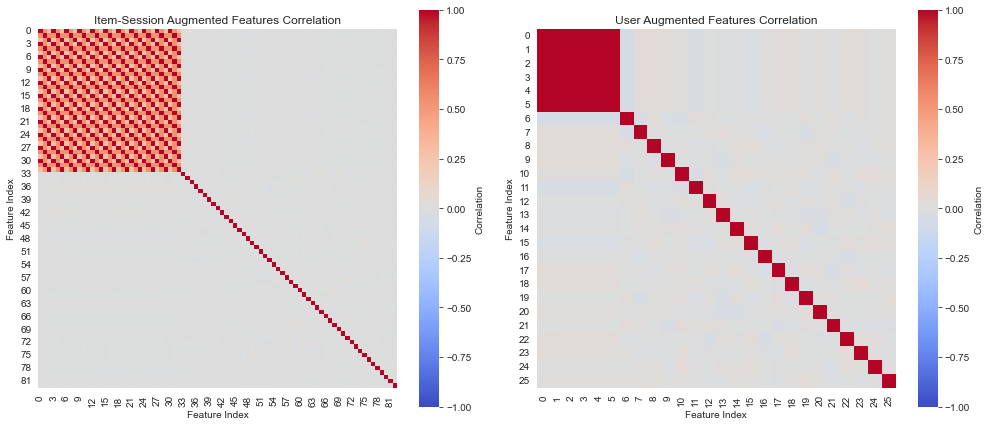

Item-session augmented features shape: torch.Size([2779, 4, 83])
User augmented features shape: torch.Size([2779, 26])
Max correlation (item-session, off-diagonal): 1.000
Max correlation (user, off-diagonal): 1.000


In [31]:
# %% Visualize correlation structure in augmented features
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix for item-session augmented features (averaged over sessions and items)
# Shape: (N, I, D) -> flatten to (N*I, D) for correlation
itemsession_flat = itemsession_augmented.reshape(-1, itemsession_augmented.shape[2]).cpu().numpy()
corr_is = np.corrcoef(itemsession_flat.T)

# Compute correlation matrix for user-level augmented features
user_flat = user_augmented.cpu().numpy()
corr_user = np.corrcoef(user_flat.T)

# Plot correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Item-session features correlation
sns.heatmap(corr_is, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Correlation'}, ax=axes[0])
axes[0].set_title('Item-Session Augmented Features Correlation')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Feature Index')

# User features correlation
sns.heatmap(corr_user, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Correlation'}, ax=axes[1])
axes[1].set_title('User Augmented Features Correlation')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Feature Index')

plt.tight_layout()
plt.show()

print(f"Item-session augmented features shape: {itemsession_augmented.shape}")
print(f"User augmented features shape: {user_augmented.shape}")
print(f"Max correlation (item-session, off-diagonal): {np.max(np.abs(corr_is - np.eye(corr_is.shape[0]))):.3f}")
print(f"Max correlation (user, off-diagonal): {np.max(np.abs(corr_user - np.eye(corr_user.shape[0]))):.3f}")


In [32]:
# %% Train model with high-dimensional features
from torch_choice.model import ConditionalLogitModel
from torch_choice import run

# High-dimensional formula including noisy and correlated features
formula_hd = ' (itemsession_augmented|constant) + (user_augmented|item) + (itemsession_ivt|item-full) + (intercept|item) '

def fit_and_report(reg=None, alpha=None, epochs=3000, lr=0.01):
    model = ConditionalLogitModel(
        formula=formula_hd,
        dataset=augmented_dataset,
        num_items=augmented_dataset.num_items,
        regularization=reg,
        regularization_weight=alpha
    ).to(device)

    # Use lightning run helper; skip std errors for speed
    trained_model = run(
        model,
        augmented_dataset,
        dataset_val=None,
        dataset_test=None,
        num_epochs=epochs,
        learning_rate=lr,
        batch_size=-1,
        model_optimizer='Adam',
        report_std=False
    )

    # Evaluate and summarize metrics
    with torch.no_grad():
        train_ll = - trained_model.negative_log_likelihood(augmented_dataset, augmented_dataset.item_index).detach().item()
        l2_norm = sum(p.norm(p=2) for _, p in trained_model.named_parameters()).item()
        l1_norm = sum(p.norm(p=1) for _, p in trained_model.named_parameters()).item()
        nonzero = sum((p.abs() > 1e-4).sum().item() for _, p in trained_model.named_parameters())
        total = sum(p.numel() for _, p in trained_model.named_parameters())
    print(f'Reg={reg}, alpha={alpha} | Train LL={train_ll:.3f} | L2={l2_norm:.2f} | L1={l1_norm:.2f} | Nonzero={nonzero}/{total}')

    # Plot distribution of coefficients
    all_params = []
    with torch.no_grad():
        for _, p in trained_model.named_parameters():
            all_params.extend(p.flatten().cpu().numpy())

    plt.figure(figsize=(8, 4))
    plt.hist(all_params, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Coefficients (Reg={reg}, alpha={alpha})')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return trained_model


/Users/tianyudu/Development/torch-choice/torch_choice/data/choice_dataset.py:241: UserWarning: The number of users is inferred from the number of unique users in the user_index tensor. This might lead to unexpected behaviors if some users never appeared in the user_index tensor. For a safer behavior, please provide the number of users explicitly by using the num_users keyword while initializing the ChoiceDataset class.
  warnings.warn(f"The number of users is inferred from the number of unique users in the user_index tensor. This might lead to unexpected behaviors if some users never appeared in the user_index tensor. For a safer behavior, please provide the number of users explicitly by using the num_users keyword while initializing the ChoiceDataset class.")
/Users/tianyudu/Development/torch-choice/torch_choice/data/choice_dataset.py:286: UserWarning: The number of sessions is inferred from the number of unique sessions in the session_index tensor. This might lead to unexpected behav

==================== model received ====================
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_augmented[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=83, 83 trainable parameters in total, initialization=normal, device=cpu).
    (user_augmented[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=26, 78 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_augmented[constant]] with 83 parameters, with constant level variation.
X[user_augmented[item]] with 26 par

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 10 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Time taken for training: 1.7179648876190186
Skip testing, no test dataset is provided.
Reg=None, alpha=None | Train LL=-122546.781 | L2=21.02 | L1=125.50 | Nonzero=168/168


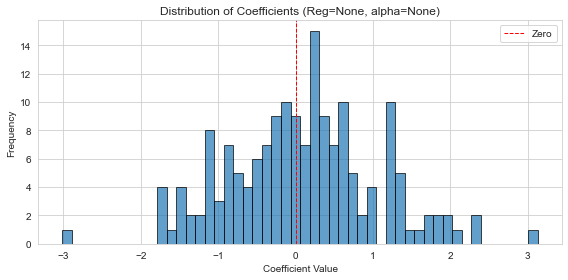

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 168   
------------------------------------------------
168       Trainable params
0         Non-trainable params
168       Total params
0.001     Total estimated model params size (MB)


==================== model received ====================
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_augmented[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=83, 83 trainable parameters in total, initialization=normal, device=cpu).
    (user_augmented[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=26, 78 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_augmented[constant]] with 83 parameters, with constant level variation.
X[user_augmented[item]] with 26 par

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Time taken for training: 1.6851279735565186
Skip testing, no test dataset is provided.
Reg=L2, alpha=5.0 | Train LL=-107353.328 | L2=17.69 | L1=117.73 | Nonzero=168/168


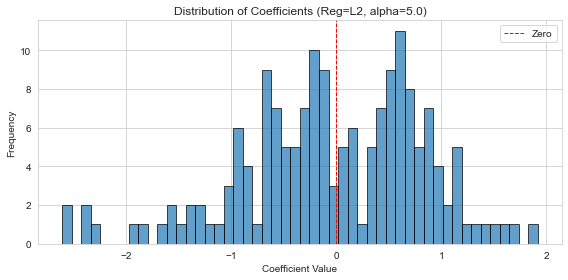

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 168   
------------------------------------------------
168       Trainable params
0         Non-trainable params
168       Total params
0.001     Total estimated model params size (MB)


==================== model received ====================
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_augmented[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=83, 83 trainable parameters in total, initialization=normal, device=cpu).
    (user_augmented[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=26, 78 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_augmented[constant]] with 83 parameters, with constant level variation.
X[user_augmented[item]] with 26 par

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Time taken for training: 1.8543639183044434
Skip testing, no test dataset is provided.
Reg=L1, alpha=5.0 | Train LL=-180841.984 | L2=16.61 | L1=103.66 | Nonzero=168/168


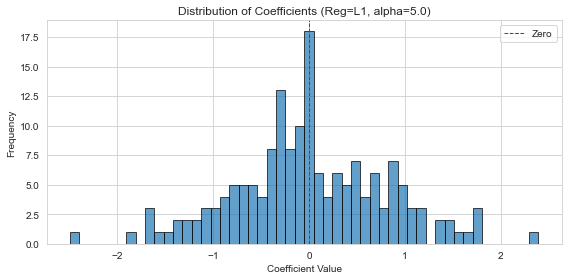

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 168   
------------------------------------------------
168       Trainable params
0         Non-trainable params
168       Total params
0.001     Total estimated model params size (MB)


==================== model received ====================
ConditionalLogitModel(
  (coef_dict): ModuleDict(
    (itemsession_augmented[constant]): Coefficient(variation=constant, num_items=4, num_users=None, num_params=83, 83 trainable parameters in total, initialization=normal, device=cpu).
    (user_augmented[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=26, 78 trainable parameters in total, initialization=normal, device=cpu).
    (itemsession_ivt[item-full]): Coefficient(variation=item-full, num_items=4, num_users=None, num_params=1, 4 trainable parameters in total, initialization=normal, device=cpu).
    (intercept[item]): Coefficient(variation=item, num_items=4, num_users=None, num_params=1, 3 trainable parameters in total, initialization=normal, device=cpu).
  )
)
Conditional logistic discrete choice model, expects input features:

X[itemsession_augmented[constant]] with 83 parameters, with constant level variation.
X[user_augmented[item]] with 26 par

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


Time taken for training: 2.071294069290161
Skip testing, no test dataset is provided.
Reg=L1, alpha=10.0 | Train LL=-158091.969 | L2=21.68 | L1=121.07 | Nonzero=168/168


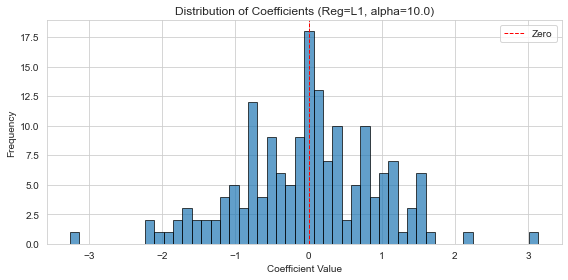

In [33]:
# %% Compare unregularized vs L2 vs L1 regularization
# Unregularized (expect larger norms, worse test LL due to overfitting to noise)
_ = fit_and_report(reg=None, alpha=None, epochs=100, lr=0.01)

# L2 regularization (expect smaller norms, better generalization)
_ = fit_and_report(reg='L2', alpha=5.0, epochs=100, lr=0.01)

# L1 regularization (expect sparsity; many coefficients near zero)
_ = fit_and_report(reg='L1', alpha=5.0, epochs=100, lr=0.01)

# Optional stronger L1 for more sparsity
_ = fit_and_report(reg='L1', alpha=10.0, epochs=100, lr=0.01)

## Using custom PyTorch Lightning callbacks (EarlyStopping)

**How to customize training with callbacks:**
- TorchChoice exposes a Lightning-based trainer internally.
- To customize callbacks (e.g., EarlyStopping with your own monitor/patience), wrap the model with the Lightning wrapper and instantiate a `pl.Trainer` with your callbacks.

**Important notes:**
- The Lightning wrapper logs validation metrics under names like `val_log_likelihood`. Monitor that for early stopping with `mode='max'`.
- Provide a validation split to enable early stopping.
- This example uses the high-dimensional dataset built above to keep context consistent.


In [34]:
# %% Custom EarlyStopping with Lightning
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from torch_choice.utils.run_helper_lightning import LightningModelWrapper

# Clone the augmented_dataset for train and validation
train_ds2 = augmented_dataset.clone()
val_ds2 = augmented_dataset.clone()

# Define a compact model to speed up the demo
formula_callbacks = ' (itemsession_augmented|constant) + (user_augmented|item) + (intercept|item) '
model_cb = ConditionalLogitModel(
    formula=formula_callbacks,
    dataset=train_ds2,
    num_items=train_ds2.num_items,
    regularization='L2',
    regularization_weight=0.01
).to(device)

# Wrap with Lightning and set callbacks
lightning_model = LightningModelWrapper(model_cb, learning_rate=0.01, model_optimizer='Adam')
callbacks = [
    EarlyStopping(monitor='val_log_likelihood', mode='max', patience=5, min_delta=0.001),
    LearningRateMonitor(logging_interval='epoch')
]

# DataLoader
from torch_choice.data.utils import create_data_loader
train_loader = create_data_loader(train_ds2.to(device), batch_size=-1, shuffle=True)
val_loader = create_data_loader(val_ds2.to(device), batch_size=-1, shuffle=False)

# Trainer with custom callbacks
trainer = pl.Trainer(
    accelerator='cuda' if 'cuda' in str(device) else 'cpu',
    devices='auto',
    max_epochs=500,
    check_val_every_n_epoch=1,
    log_every_n_steps=1,
    callbacks=callbacks,
)

trainer.fit(lightning_model, train_loader, val_loader)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type                  | Params
------------------------------------------------
0 | model | ConditionalLogitModel | 164   
------------------------------------------------
164       Trainable params
0         Non-trainable params
164       Total params
0.001     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/Users/tianyudu/miniforge3/envs/dev/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 10 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

# References

- **GitHub Repository**: [https://github.com/gsbDBI/torch-choice](https://github.com/gsbDBI/torch-choice)
- **Online Documentation**: [https://gsbdbi.github.io/torch-choice/](https://gsbdbi.github.io/torch-choice/)
- **Paper**: [https://arxiv.org/abs/2304.01906](https://arxiv.org/abs/2304.01906)